<a href="https://colab.research.google.com/github/mametaro99/fMRI-ALS-HC-classification/blob/main/FMRI_ReccurenceTriangle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import os
import glob

def load_fmri_file(file_path, group_name):
    """
    Reads an fMRI data file, extracts the Subject ID from the filename,
    and adds SubjectID and Group columns.
    """
    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path)

    # Extract the base filename
    filename = os.path.basename(file_path)

    # Parse the Subject ID (assumes format like 'sub-HC5001_...')
    subject_id = filename.split('_')[0]

    # Assign new columns
    df['SubjectID'] = subject_id
    df['Group'] = group_name

    return df

In [8]:
import io
import pandas as pd

from google.colab import auth
auth.authenticate_user()

from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload

# -----------------------------
# Drive API
# -----------------------------
drive_service = build("drive", "v3")

ALS_FOLDER_ID = "1dcGOujAwNrOhxtiw6-mV_UjrV1stxYbl"
HC_FOLDER_ID  = "16i40sw1HeyeU9-kc6leTsXxbzpYwyAKv"

FOLDER_MIME = "application/vnd.google-apps.folder"


# -----------------------------
# フォルダ直下のファイル一覧
# -----------------------------
def list_files_in_folder(folder_id):
    query = f"'{folder_id}' in parents and trashed = false"
    results = drive_service.files().list(
        q=query,
        fields="files(id, name, mimeType)",
        pageSize=1000
    ).execute()
    return results.get("files", [])


# -----------------------------
# 再帰的にCSVだけ集める
# -----------------------------
def collect_csv_files_recursive(folder_id):
    collected = []
    items = list_files_in_folder(folder_id)

    for item in items:
        if item["mimeType"] == FOLDER_MIME:
            # サブフォルダなら再帰
            collected.extend(collect_csv_files_recursive(item["id"]))
        elif item["name"].lower().endswith(".csv"):
            collected.append(item)

    return collected


# -----------------------------
# file_id から CSV を DataFrame として読む
# -----------------------------
def read_csv_from_drive(file_id):
    request = drive_service.files().get_media(fileId=file_id)
    buffer = io.BytesIO()
    downloader = MediaIoBaseDownload(buffer, request)

    done = False
    while not done:
        _, done = downloader.next_chunk()

    buffer.seek(0)
    return pd.read_csv(buffer)


# -----------------------------
# 1ファイル分の読み込み
# 必要に応じて列名整形など追加
# -----------------------------
def load_fmri_file(file_info, label):
    df = read_csv_from_drive(file_info["id"]).copy()
    df["group"] = label
    df["source_file"] = file_info["name"]
    return df


# -----------------------------
# CSV収集
# -----------------------------
als_files = collect_csv_files_recursive(ALS_FOLDER_ID)
hc_files  = collect_csv_files_recursive(HC_FOLDER_ID)

print("ALS csv files:", len(als_files))
for f in als_files[:5]:
    print("  ", f["name"], f["id"])

print("HC csv files:", len(hc_files))
for f in hc_files[:5]:
    print("  ", f["name"], f["id"])


# -----------------------------
# DataFrame結合
# -----------------------------
data_frames = []

for file_info in als_files:
    df = load_fmri_file(file_info, "ALS")
    data_frames.append(df)

for file_info in hc_files:
    df = load_fmri_file(file_info, "HC")
    data_frames.append(df)

fmri_data = pd.concat(data_frames, ignore_index=True)

print("Shape of combined DataFrame:", fmri_data.shape)
display(fmri_data)

ALS csv files: 24
   sub-ALSPLS004_task-rest_dir-PA_space-MNI152NLin6Asym_seg-4S156Parcels_stat-mean_timeseries.csv 1Nu6o1jrK1KL8RSuN0kV-WhZibuIbEEkZ
   sub-ALS033_task-rest_dir-PA_space-MNI152NLin6Asym_seg-4S156Parcels_stat-mean_timeseries.csv 1FyLtJ1j-zqICGJWMk6krDorKs0d0NJQv
   sub-ALS032_task-rest_dir-PA_space-MNI152NLin6Asym_seg-4S156Parcels_stat-mean_timeseries.csv 17jskalR83f_Y4hJKilId90W5Bl3oHTgA
   sub-ALS031_task-rest_dir-PA_space-MNI152NLin6Asym_seg-4S156Parcels_stat-mean_timeseries.csv 1rex0n5g13PIfw8Ltk5hhG1Ggxe4WwDPW
   sub-ALS030_task-rest_dir-PA_space-MNI152NLin6Asym_seg-4S156Parcels_stat-mean_timeseries.csv 1o-FUytixHfqZBhHi3W-TgQB7r-1XtHgr
HC csv files: 24
   sub-HC6007_task-rest_dir-PA_space-MNI152NLin6Asym_seg-4S156Parcels_stat-mean_timeseries.csv 11BZOw2GYqa_doyqNIwGY1jYfyE_Or1LN
   sub-HC7006_task-rest_dir-PA_space-MNI152NLin6Asym_seg-4S156Parcels_stat-mean_timeseries.csv 1rIjMcWXupkSI4hkirdd3vVtNbkGP1jcb
   sub-HC7007_task-rest_dir-PA_space-MNI152NLin6Asym_seg-4S

,LH_Vis_1_Fusiform_L,LH_Vis_2_Fusiform_L,LH_Vis_3_Lingual_L,LH_Vis_4_Occipital_Mid_L,LH_Vis_5_Calcarine_L,LH_Vis_6_Calcarine_L,LH_Vis_7_Temporal_Mid_L,LH_Vis_8_Occipital_Mid_L,LH_Vis_9_Cuneus_L,LH_SomMot_1_Temporal_Sup_L,...,Cerebellar_Region3_LeftHemisphere,Cerebellar_Region4_LeftHemisphere,Cerebellar_Region5_LeftHemisphere,Cerebellar_Region6_RightHemisphere,Cerebellar_Region7_LeftHemisphere,Cerebellar_Region8_RightHemisphere,Cerebellar_Region9_RightHemisphere,Cerebellar_Region10_LeftHemisphere,group,source_file
0,0.659899,0.474176,1.113970,0.383730,0.731779,0.791733,0.030415,0.407028,0.748130,-0.987001,...,-0.391977,-0.359210,0.107012,-0.013251,-0.123381,0.956467,0.432258,0.367473,ALS,sub-ALSPLS004_task-rest_dir-PA_space-MNI152NLi...
1,0.135694,0.960673,-0.345874,1.934692,1.570930,1.039831,-0.184959,-0.667202,-0.287384,0.414777,...,-0.429717,-0.367912,0.421250,-0.235084,1.272944,1.384500,0.385935,0.467817,ALS,sub-ALSPLS004_task-rest_dir-PA_space-MNI152NLi...
2,-0.233580,3.053868,-0.254062,3.834575,3.919217,2.235851,0.380700,0.260332,0.043457,1.800574,...,0.221141,0.482651,0.999281,0.289586,2.123519,1.142630,0.648714,0.380323,ALS,sub-ALSPLS004_task-rest_dir-PA_space-MNI152NLi...
3,-0.136169,4.618473,0.322399,4.257414,5.024313,2.351772,1.110155,2.002550,0.812399,2.317119,...,1.632144,2.035630,1.705305,1.364686,1.885215,0.393927,0.815867,0.336012,ALS,sub-ALSPLS004_task-rest_dir-PA_space-MNI152NLi...
4,0.118256,4.132984,-0.228453,2.901738,3.453336,0.455231,1.330036,2.780549,0.886701,2.133701,...,3.248963,2.842216,2.402359,2.391043,1.411407,0.269060,0.835317,0.441388,ALS,sub-ALSPLS004_task-rest_dir-PA_space-MNI152NLi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10988,-0.072084,-5.203897,-2.401166,-4.589603,-5.111739,-3.402066,-0.703763,-1.579761,-2.125845,-0.174305,...,-0.221489,-0.169129,0.034675,0.418585,0.193476,-0.174845,0.443857,0.468883,HC,sub-HC5009_task-rest_dir-PA_space-MNI152NLin6A...
10989,-0.039622,-8.310687,-2.614275,-7.272248,-6.282058,-3.008543,-1.324715,-2.392373,-2.547850,-1.023778,...,0.037870,0.409891,0.577696,0.883006,0.243978,0.176757,1.763444,1.060264,HC,sub-HC5009_task-rest_dir-PA_space-MNI152NLin6A...
10990,-0.062095,-7.644165,-1.824637,-6.277320,-5.216956,-2.127247,-1.700989,-2.458739,-2.340497,-1.170816,...,-0.056981,0.263075,0.628662,0.725696,0.023399,0.501710,2.361734,0.938836,HC,sub-HC5009_task-rest_dir-PA_space-MNI152NLin6A...
10991,-0.157293,-4.004753,-0.632181,-3.085820,-2.288770,-0.914631,-1.737345,-1.865804,-1.520465,-0.697717,...,0.147330,0.341351,0.521713,0.545637,-0.253502,0.780402,1.980130,0.564361,HC,sub-HC5009_task-rest_dir-PA_space-MNI152NLin6A...


In [9]:
!pip install optuna
import numpy as np
import pandas as pd

# -----------------------------
# 1) SubjectID を source_file から作る
#    例: sub-ALS033_task-rest_...csv -> sub-ALS033
# -----------------------------
if "SubjectID" not in fmri_data.columns:
    fmri_data["SubjectID"] = fmri_data["source_file"].astype(str).str.split("_").str[0]

# -----------------------------
# 2) ラベルを数値化
# -----------------------------
label_map = {"HC": 0, "ALS": 1}

# 念のため group 列の値を確認
print("Unique labels in group column:", fmri_data["group"].unique())

# -----------------------------
# 3) SubjectID ごとにまとめる
# -----------------------------
grouped = fmri_data.groupby("SubjectID")

X_seq = []
y = []
subject_ids = []

for subject_id, group_df in grouped:
    group_df = group_df.copy()

    # 時系列順に並べる
    if "index" in group_df.columns:
        group_df = group_df.sort_values("index")

    # ラベルは各被験者で一定
    label_str = group_df["group"].iloc[0]
    label_num = label_map[label_str]

    # メタデータ列を除外
    drop_cols = [c for c in ["SubjectID", "group", "source_file"] if c in group_df.columns]

    # index列は時系列添字なので特徴から除外
    if "index" in group_df.columns:
        drop_cols.append("index")

    subject_data = group_df.drop(columns=drop_cols).to_numpy(dtype=np.float32)

    X_seq.append(subject_data)
    y.append(label_num)
    subject_ids.append(subject_id)

y = np.array(y, dtype=np.int64)

print(f"Total number of subjects: {len(X_seq)}")
if len(X_seq) > 0:
    print(f"Shape of first subject's data: {X_seq[0].shape}")

print("First 10 subject IDs:", subject_ids[:10])
print("Class balance [HC, ALS]:", np.bincount(y))

Unique labels in group column: ['ALS' 'HC']
Total number of subjects: 48
Shape of first subject's data: (218, 156)
First 10 subject IDs: ['sub-ALS001', 'sub-ALS002', 'sub-ALS003', 'sub-ALS005', 'sub-ALS006', 'sub-ALS009', 'sub-ALS010', 'sub-ALS014', 'sub-ALS015', 'sub-ALS016']
Class balance [HC, ALS]: [24 24]


In [10]:
!pip install scikit-optimize

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter
from concurrent.futures import ProcessPoolExecutor
from numpy.lib.stride_tricks import sliding_window_view
import os

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from skopt import BayesSearchCV
from skopt.space import Real, Categorical


# =========================================================
# 0) fmri_data から患者ごとの時系列行列を作る
# =========================================================

def get_signal_columns(df):
    exclude_cols = {"group", "source_file"}
    # "index" 列は時系列の添字として入っているので除外
    signal_cols = [c for c in df.columns if c not in exclude_cols and c != "index"]
    return signal_cols


import re
import numpy as np
import pandas as pd

def build_subject_matrices(fmri_data: pd.DataFrame):
    df = fmri_data.copy()

    # -----------------------------
    # 1) SubjectID を source_file から作る
    #    例: sub-ALS033_task-rest_...csv -> sub-ALS033
    # -----------------------------
    if "SubjectID" not in df.columns:
        if "source_file" not in df.columns:
            raise ValueError("source_file 列が存在しないため SubjectID を作れません。")

        def extract_subject_id(s):
            s = str(s)
            m = re.match(r"^(sub-[^_]+)", s)
            if m:
                return m.group(1)
            return s.split("_")[0]

        df["SubjectID"] = df["source_file"].astype(str).apply(extract_subject_id)

    # -----------------------------
    # 2) ラベルを数値化
    # -----------------------------
    label_map = {"HC": 0, "ALS": 1}

    print("Unique labels in group column:", df["group"].unique())
    unknown = sorted(set(df["group"].dropna().unique()) - set(label_map.keys()))
    if unknown:
        raise ValueError(f"未対応の group ラベルがあります: {unknown}")

    # -----------------------------
    # 3) 特徴量列を決める
    #    -> 数値列のみ使用
    # -----------------------------
    exclude_cols = {
        "SubjectID", "group", "source_file", "index"
    }

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    signal_cols = [c for c in numeric_cols if c not in exclude_cols]

    if len(signal_cols) == 0:
        raise ValueError("数値の特徴量列が見つかりません。列構成を確認してください。")

    print("Number of numeric signal columns:", len(signal_cols))
    print("First few signal columns:", signal_cols[:10])

    # -----------------------------
    # 4) SubjectID ごとにまとめる
    # -----------------------------
    grouped = df.groupby("SubjectID", sort=True)

    X_subjects = []
    y = []
    subject_ids = []

    for subject_id, group_df in grouped:
        group_df = group_df.copy()

        if "index" in group_df.columns:
            group_df = group_df.sort_values("index")

        # 各被験者でラベルは1つであることを確認
        labels = group_df["group"].dropna().unique()
        if len(labels) != 1:
            print(f"[skip] {subject_id}: group が一意ではありません -> {labels}")
            continue

        label_str = labels[0]
        label_num = label_map[label_str]

        # 数値列だけを使って行列化
        subject_data = group_df[signal_cols].to_numpy(dtype=np.float32)

        # NaN / inf 対策
        subject_data = np.nan_to_num(subject_data, nan=0.0, posinf=0.0, neginf=0.0)

        if subject_data.ndim != 2 or subject_data.shape[0] == 0 or subject_data.shape[1] == 0:
            print(f"[skip] {subject_id}: invalid shape {subject_data.shape}")
            continue

        X_subjects.append(subject_data)
        y.append(label_num)
        subject_ids.append(subject_id)

    y = np.asarray(y, dtype=np.int64)

    print("Number of subjects:", len(subject_ids))
    if len(X_subjects) > 0:
        print("Example subject shape:", X_subjects[0].shape)
    print("Class balance (HC=0, ALS=1):", np.bincount(y) if len(y) > 0 else "empty")

    return subject_ids, X_subjects, y, signal_cols

# =========================================================
# 1) クロスリカレンスプロット
# =========================================================

def cross_recurrence_plot_1d(x, y, percentage=0.1):
    """
    x, y: shape [T]
    percentage: 上位何%を recurrence とみなすか（例 0.1 -> 10%）
    Returns
    -------
    R : np.ndarray, shape [T, T], dtype uint8
    """
    x = np.asarray(x, dtype=np.float32).ravel()
    y = np.asarray(y, dtype=np.float32).ravel()

    # |x_i - y_j|
    D = np.abs(x[:, None] - y[None, :])

    # 閾値
    thr = np.percentile(D, percentage * 100.0)

    R = (D < thr).astype(np.uint8)
    return R


# =========================================================
# 2) 再帰三角形 L=4 の頻度分布
#    上三角 6 bit -> 64パターン
# =========================================================

def extract_triangle_histogram_from_rp(rp, L=4, normalize=False):
    """
    rp : binary matrix [T, T]
    L  : triangle size

    Returns
    -------
    hist : np.ndarray shape [2^(L*(L-1)/2)]
    """
    rp = np.asarray(rp, dtype=np.uint8)
    n = rp.shape[0]
    if n < L:
        dim = 2 ** (L * (L - 1) // 2)
        return np.zeros(dim, dtype=np.float64)

    # [n-L+1, n-L+1, L, L]
    windows = sliding_window_view(rp, (L, L))
    # shape: (n-L+1, n-L+1, L, L)

    tri_i, tri_j = np.triu_indices(L, k=1)  # 上三角（対角除く）
    bits = windows[..., tri_i, tri_j]       # shape: [m, m, n_bits]

    n_bits = bits.shape[-1]
    weights = (1 << np.arange(n_bits, dtype=np.int64))  # [1,2,4,8,...]
    codes = np.tensordot(bits, weights, axes=([-1], [0])).ravel()

    dim = 2 ** n_bits
    hist = np.bincount(codes, minlength=dim).astype(np.float64)

    if normalize and hist.sum() > 0:
        hist /= hist.sum()

    return hist


# =========================================================
# 3) 1患者分の特徴量作成
#    すべてのチャネルペアの CRP -> 三角形頻度を合算
# =========================================================

def subject_feature_from_all_pairs(X_subject, L=4, percentage=0.1, normalize_each_pair=False):
    """
    X_subject : shape [T, C]
    Returns
    -------
    feat : shape [64] (L=4 の場合)
    """
    T, C = X_subject.shape
    n_patterns = 2 ** (L * (L - 1) // 2)

    total_hist = np.zeros(n_patterns, dtype=np.float64)

    for i, j in combinations(range(C), 2):
        rp = cross_recurrence_plot_1d(X_subject[:, i], X_subject[:, j], percentage=percentage)
        hist = extract_triangle_histogram_from_rp(rp, L=L, normalize=normalize_each_pair)
        total_hist += hist


    # 患者単位で正規化
    if total_hist.sum() > 0:
        total_hist /= total_hist.sum()

    return total_hist


def _subject_feature_worker(args):
    x_subject, L, percentage, normalize_each_pair = args
    return subject_feature_from_all_pairs(
        x_subject,
        L=L,
        percentage=percentage,
        normalize_each_pair=normalize_each_pair
    )


def build_feature_matrix(
    X_subjects,
    L=4,
    percentage=0.1,
    normalize_each_pair=False,
    n_jobs=1
):
    """
    Returns
    -------
    X_feat : shape [n_subjects, 64]
    """
    args_list = [(x, L, percentage, normalize_each_pair) for x in X_subjects]

    if n_jobs == 1:
        feats = [_subject_feature_worker(a) for a in args_list]
    else:
        with ProcessPoolExecutor(max_workers=n_jobs) as ex:
            feats = list(ex.map(_subject_feature_worker, args_list))

    return np.vstack(feats)


# =========================================================
# 4) 可視化（任意）
# =========================================================

def plot_sample_crp_and_hist(X_subjects, y, subject_ids, signal_cols, subject_index=0, ch_i=0, ch_j=1, L=4, percentage=0.1):
    x = X_subjects[subject_index]
    rp = cross_recurrence_plot_1d(x[:, ch_i], x[:, ch_j], percentage=percentage)
    hist = extract_triangle_histogram_from_rp(rp, L=L, normalize=True)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(x[:, ch_i], lw=1)
    axes[0].set_title(f"{subject_ids[subject_index]} / {signal_cols[ch_i]}")
    axes[0].set_xlabel("Time")

    axes[1].plot(x[:, ch_j], lw=1)
    axes[1].set_title(f"{subject_ids[subject_index]} / {signal_cols[ch_j]}")
    axes[1].set_xlabel("Time")

    axes[2].imshow(rp, cmap="Greys", origin="lower")
    axes[2].set_title(f"CRP ({signal_cols[ch_i]} vs {signal_cols[ch_j]})")
    axes[2].set_xlabel("Time")
    axes[2].set_ylabel("Time")

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.bar(np.arange(len(hist)), hist)
    plt.title(f"Triangle histogram (L={L})")
    plt.xlabel("Pattern code")
    plt.ylabel("Normalized frequency")
    plt.tight_layout()
    plt.show()


Number of subjects: 48
Number of channels: 156
Example shape: (218, 156)
Class balance (HC=0, ALS=1): [24 24]


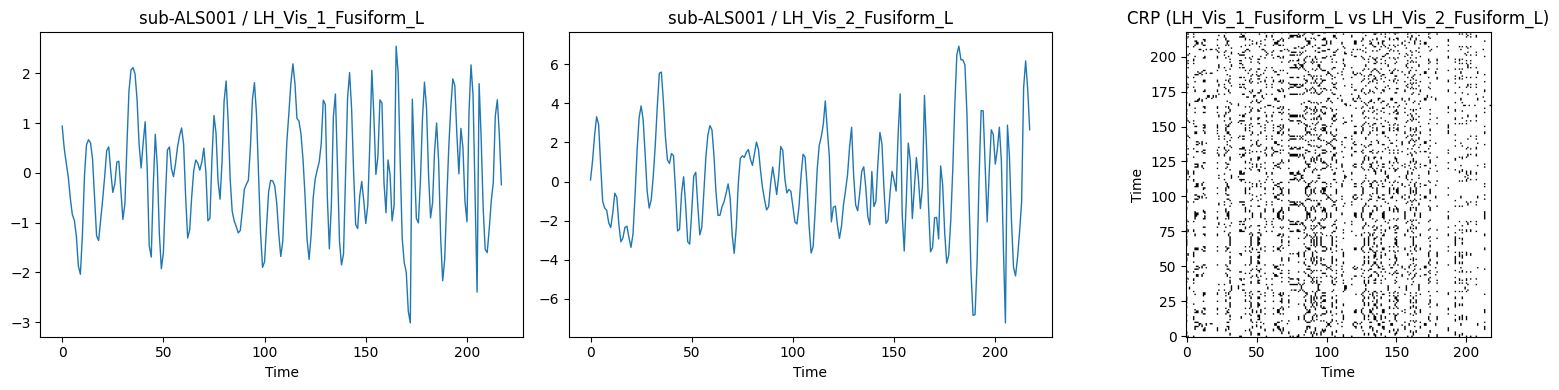

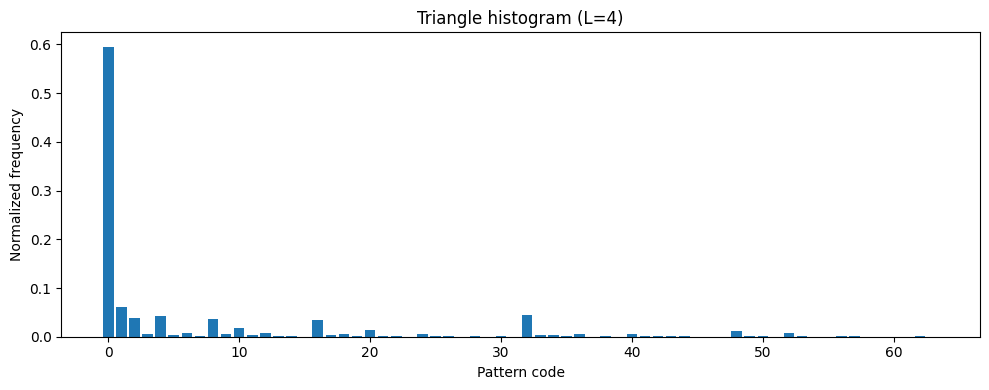

In [51]:

# =========================================================
# 5) ネスト交差検証 + BayesSearchCV + 線形SVM
# =========================================================

def nested_cv_bayes_linear_svm(
    X, y,
    n_splits_outer=5,
    n_splits_inner=3,
    n_iter=20,
    random_state=42
):
    """
    線形SVMを BayesSearchCV で最適化し、
    outer CV の精度を評価する。
    """
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.int64)

    outer_cv = StratifiedKFold(n_splits=n_splits_outer, shuffle=True, random_state=random_state)

    oof_pred = np.empty_like(y)
    accs, precs, recs, f1s = [], [], [], []
    cms = []
    best_params_each_fold = []

    for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X, y), start=1):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        inner_cv = StratifiedKFold(n_splits=n_splits_inner, shuffle=True, random_state=random_state + fold)

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(kernel="linear", probability=False, random_state=random_state))
        ])

        search_spaces = {
            "svm__C": Real(1e1, 1e5, prior="log-uniform"),
            "svm__class_weight": Categorical([None, "balanced"])
        }

        opt = BayesSearchCV(
            estimator=pipe,
            search_spaces=search_spaces,
            n_iter=n_iter,
            cv=inner_cv,
            scoring="accuracy",
            n_jobs=-1,
            random_state=random_state,
            refit=True
        )

        opt.fit(X_tr, y_tr)
        best_model = opt.best_estimator_

        y_pred = best_model.predict(X_te)
        oof_pred[te_idx] = y_pred

        acc = accuracy_score(y_te, y_pred)
        prec = precision_score(y_te, y_pred, average="binary", zero_division=0)
        rec = recall_score(y_te, y_pred, average="binary", zero_division=0)
        f1 = f1_score(y_te, y_pred, average="binary", zero_division=0)
        cm = confusion_matrix(y_te, y_pred, labels=[0, 1])

        accs.append(acc)
        precs.append(prec)
        recs.append(rec)
        f1s.append(f1)
        cms.append(cm)
        best_params_each_fold.append(opt.best_params_)

        print(f"\n[Fold {fold}]")
        print("Best params:", opt.best_params_)
        print(f"Accuracy : {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall   : {rec:.4f}")
        print(f"F1       : {f1:.4f}")
        print("Confusion matrix:\n", cm)

    cm_sum = np.sum(cms, axis=0)

    print("\n========== Nested CV Result ==========")
    print(f"Accuracy : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f}")
    print(f"Recall   : {np.mean(recs):.4f}")
    print(f"F1       : {np.mean(f1s):.4f}")

    print("\nOOF classification report:")
    print(classification_report(y, oof_pred, target_names=["HC", "ALS"], zero_division=0))

    return {
        "accuracy_mean": float(np.mean(accs)),
        "accuracy_std": float(np.std(accs)),
        "accuracy_by_fold": [float(v) for v in accs],
        "precision_mean": float(np.mean(precs)),
        "recall_mean": float(np.mean(recs)),
        "f1_mean": float(np.mean(f1s)),
        "confusion_sum": cm_sum,
        "oof_pred": oof_pred,
        "best_params_each_fold": best_params_each_fold,
    }


def plot_confusion_matrix(cm, class_names=("HC", "ALS"), title="Confusion Matrix"):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()




# =========================================================
# 6) 実行
# =========================================================

# fmri_data がすでに作成済みであることを前提
subject_ids, X_subjects, y, signal_cols = build_subject_matrices(fmri_data)

print("Number of subjects:", len(subject_ids))
print("Number of channels:", len(signal_cols))
print("Example shape:", X_subjects[0].shape)
print("Class balance (HC=0, ALS=1):", np.bincount(y))


# ---- 任意: サンプルの CRP 可視化 ----
plot_sample_crp_and_hist(
    X_subjects, y, subject_ids, signal_cols,
    subject_index=0, ch_i=0, ch_j=1, L=4, percentage=0.1
)




Number of subjects: 48
Number of selected channels: 2
Selected signals: ['LH_Vis_1_Fusiform_L', 'LH_Vis_2_Fusiform_L']
Example shape: (218, 2)
Class balance (HC=0, ALS=1): [24 24]
Using n_jobs = 4


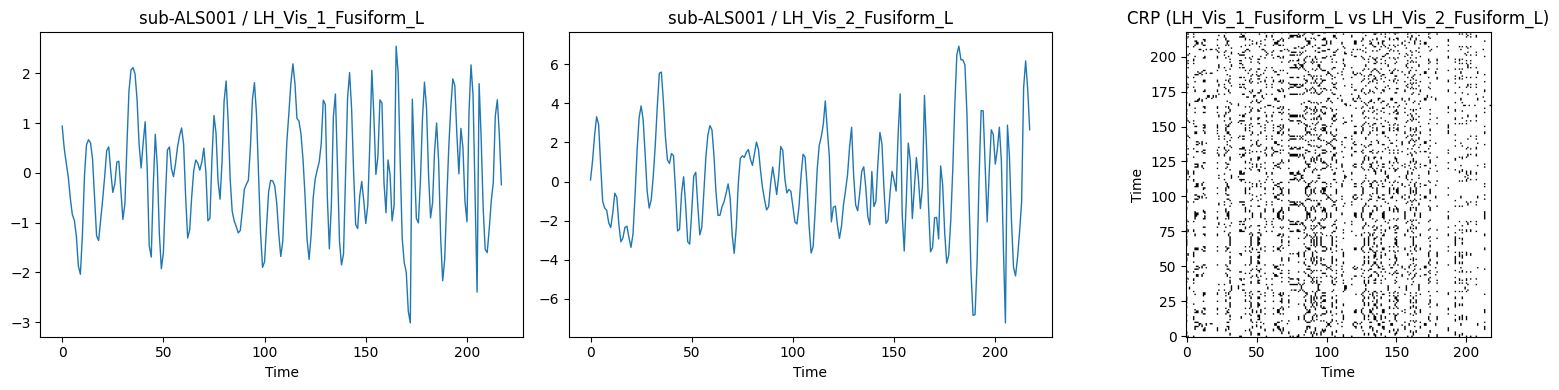

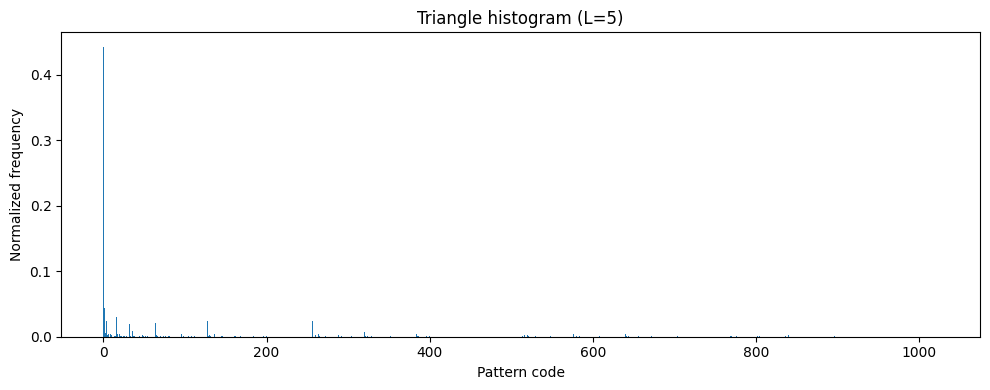

Feature matrix shape: (48, 1024)
=== Linear SVM ===

[Fold 1]
Best params: OrderedDict({'svm__C': 1592.5169151603525, 'svm__class_weight': 'balanced'})
Accuracy : 0.6000
Precision: 0.6000
Recall   : 0.6000
F1       : 0.6000
Confusion matrix:
 [[3 2]
 [2 3]]

[Fold 2]
Best params: OrderedDict({'svm__C': 169.94636371262763, 'svm__class_weight': 'balanced'})
Accuracy : 0.4000
Precision: 0.4286
Recall   : 0.6000
F1       : 0.5000
Confusion matrix:
 [[1 4]
 [2 3]]


/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [10000.0, np.str_('balanced')] before, using random point [89.48354752833222, None]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [10000.0, np.str_('balanced')] before, using random point [2206.257289637174, 'balanced']
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [10000.0, np.str_('balanced')] before, using random point [152.16830560758444, None]
  warnings.warn(



[Fold 3]
Best params: OrderedDict({'svm__C': 10000.0, 'svm__class_weight': 'balanced'})
Accuracy : 0.7000
Precision: 0.6667
Recall   : 0.8000
F1       : 0.7273
Confusion matrix:
 [[3 2]
 [1 4]]

[Fold 4]
Best params: OrderedDict({'svm__C': 169.94636371262763, 'svm__class_weight': 'balanced'})
Accuracy : 0.6667
Precision: 0.6667
Recall   : 0.8000
F1       : 0.7273
Confusion matrix:
 [[2 2]
 [1 4]]

[Fold 5]
Best params: OrderedDict({'svm__C': 2504.1499136197735, 'svm__class_weight': None})
Accuracy : 0.6667
Precision: 0.5714
Recall   : 1.0000
F1       : 0.7273
Confusion matrix:
 [[2 3]
 [0 4]]

========== Nested CV Result ==========
Accuracy : 0.6067 ± 0.1083
Precision: 0.5867
Recall   : 0.7600
F1       : 0.6564

OOF classification report:
              precision    recall  f1-score   support

          HC       0.65      0.46      0.54        24
         ALS       0.58      0.75      0.65        24

    accuracy                           0.60        48
   macro avg       0.61      0.6

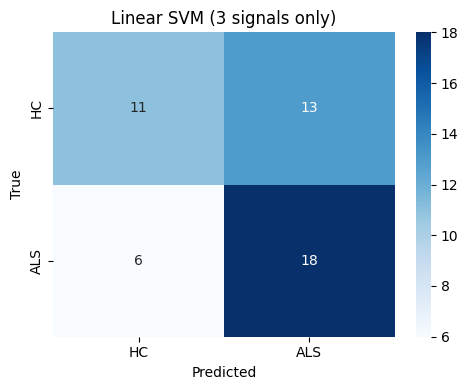


=== Random Forest ===

[RF Fold 1]
Best params: OrderedDict({'rf__class_weight': 'balanced_subsample', 'rf__max_depth': 8, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 8, 'rf__min_samples_split': 11, 'rf__n_estimators': 276})
Accuracy : 0.6000
Precision: 0.6667
Recall   : 0.4000
F1       : 0.5000
Confusion matrix:
 [[4 1]
 [3 2]]

[RF Fold 2]
Best params: OrderedDict({'rf__class_weight': 'balanced_subsample', 'rf__max_depth': 15, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 7, 'rf__min_samples_split': 18, 'rf__n_estimators': 774})
Accuracy : 0.5000
Precision: 0.5000
Recall   : 0.6000
F1       : 0.5455
Confusion matrix:
 [[2 3]
 [2 3]]

[RF Fold 3]
Best params: OrderedDict({'rf__class_weight': 'balanced_subsample', 'rf__max_depth': 8, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 8, 'rf__min_samples_split': 11, 'rf__n_estimators': 276})
Accuracy : 0.8000
Precision: 0.8000
Recall   : 0.8000
F1       : 0.8000
Confusion matrix:
 [[4 1]
 [1 4]]

[RF Fold 4]
Best params:

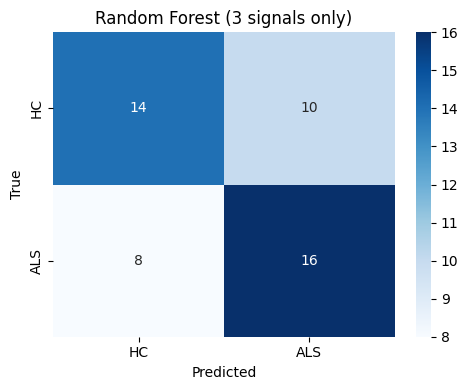


=== Summary ===
SVM Accuracy : 0.6067 ± 0.1083
SVM Precision: 0.5867
SVM Recall   : 0.7600
SVM F1       : 0.6564

RF Accuracy  : 0.6244 ± 0.1034
RF Precision : 0.6276
RF Recall    : 0.6800
RF F1        : 0.6345


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from concurrent.futures import ProcessPoolExecutor
from numpy.lib.stride_tricks import sliding_window_view
import os

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from skopt import BayesSearchCV
from skopt.space import Real, Categorical


# =========================================================
# 0) fmri_data から患者ごとの時系列行列を作る
# =========================================================

def get_signal_columns(df):
    exclude_cols = {
        "index", "SubjectID", "Group", "group", "source_file"
    }
    signal_cols = [c for c in df.columns if c not in exclude_cols]
    return signal_cols


def build_subject_matrices(fmri_data, n_signals=None):
    """
    Returns
    -------
    subject_ids : list[str]
    X_subjects  : list[np.ndarray]  # 各要素 shape = [T, n_channels]
    y           : np.ndarray        # ALS=1, HC=0
    signal_cols : list[str]
    """
    df = fmri_data.copy()

    # 列名ゆれを吸収
    if "group" in df.columns and "Group" not in df.columns:
        df = df.rename(columns={"group": "Group"})
    if "subjectid" in df.columns and "SubjectID" not in df.columns:
        df = df.rename(columns={"subjectid": "SubjectID"})

    if "SubjectID" not in df.columns:
        raise ValueError("fmri_data に 'SubjectID' 列がありません。")
    if "Group" not in df.columns:
        raise ValueError("fmri_data に 'Group' 列がありません。")

    signal_cols = get_signal_columns(df)
    if n_signals is not None:
        signal_cols = signal_cols[:n_signals]

    subject_ids = []
    X_subjects = []
    y = []

    for subject_id, g in df.groupby("SubjectID"):
        g = g.copy()

        if "index" in g.columns:
            g = g.sort_values("index")
        else:
            g = g.reset_index(drop=True)

        group_name = str(g["Group"].iloc[0]).upper()
        x = g[signal_cols].to_numpy(dtype=np.float32)
        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

        subject_ids.append(subject_id)
        X_subjects.append(x)
        y.append(1 if group_name == "ALS" else 0)

    return subject_ids, X_subjects, np.asarray(y, dtype=np.int64), signal_cols


# =========================================================
# 1) クロスリカレンスプロット
# =========================================================

def cross_recurrence_plot_1d(x, y, percentage=0.1):
    x = np.asarray(x, dtype=np.float32).ravel()
    y = np.asarray(y, dtype=np.float32).ravel()

    D = np.abs(x[:, None] - y[None, :])
    thr = np.percentile(D, percentage * 100.0)
    R = (D < thr).astype(np.uint8)
    return R


# =========================================================
# 2) 再帰三角形 L=4 の頻度分布
# =========================================================

def extract_triangle_histogram_from_rp(rp, L=4, normalize=False):
    rp = np.asarray(rp, dtype=np.uint8)
    n = rp.shape[0]
    dim = 2 ** (L * (L - 1) // 2)

    if n < L:
        return np.zeros(dim, dtype=np.float64)

    windows = sliding_window_view(rp, (L, L))
    tri_i, tri_j = np.triu_indices(L, k=1)
    bits = windows[..., tri_i, tri_j]

    n_bits = bits.shape[-1]
    weights = (1 << np.arange(n_bits, dtype=np.int64))
    codes = np.tensordot(bits, weights, axes=([-1], [0])).ravel()

    hist = np.bincount(codes, minlength=dim).astype(np.float64)

    if normalize and hist.sum() > 0:
        hist /= hist.sum()

    return hist


# =========================================================
# 3) 1患者分の特徴量作成
# =========================================================

def subject_feature_from_all_pairs(X_subject, L=4, percentage=0.1, normalize_each_pair=False):
    T, C = X_subject.shape
    n_patterns = 2 ** (L * (L - 1) // 2)
    total_hist = np.zeros(n_patterns, dtype=np.float64)

    for i, j in combinations(range(C), 2):
        rp = cross_recurrence_plot_1d(X_subject[:, i], X_subject[:, j], percentage=percentage)
        hist = extract_triangle_histogram_from_rp(rp, L=L, normalize=normalize_each_pair)
        total_hist += hist

    if total_hist.sum() > 0:
        total_hist /= total_hist.sum()

    return total_hist


def _subject_feature_worker(args):
    x_subject, L, percentage, normalize_each_pair = args
    return subject_feature_from_all_pairs(
        x_subject,
        L=L,
        percentage=percentage,
        normalize_each_pair=normalize_each_pair
    )


def build_feature_matrix(X_subjects, L=4, percentage=0.1, normalize_each_pair=False, n_jobs=1):
    args_list = [(x, L, percentage, normalize_each_pair) for x in X_subjects]

    if n_jobs == 1:
        feats = [_subject_feature_worker(a) for a in args_list]
    else:
        with ProcessPoolExecutor(max_workers=n_jobs) as ex:
            feats = list(ex.map(_subject_feature_worker, args_list))

    return np.vstack(feats)


# =========================================================
# 4) 可視化
# =========================================================

def plot_sample_crp_and_hist(X_subjects, y, subject_ids, signal_cols, subject_index=0, ch_i=0, ch_j=1, L=4, percentage=0.1):
    x = X_subjects[subject_index]
    rp = cross_recurrence_plot_1d(x[:, ch_i], x[:, ch_j], percentage=percentage)
    hist = extract_triangle_histogram_from_rp(rp, L=L, normalize=True)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(x[:, ch_i], lw=1)
    axes[0].set_title(f"{subject_ids[subject_index]} / {signal_cols[ch_i]}")
    axes[0].set_xlabel("Time")

    axes[1].plot(x[:, ch_j], lw=1)
    axes[1].set_title(f"{subject_ids[subject_index]} / {signal_cols[ch_j]}")
    axes[1].set_xlabel("Time")

    axes[2].imshow(rp, cmap="Greys", origin="lower")
    axes[2].set_title(f"CRP ({signal_cols[ch_i]} vs {signal_cols[ch_j]})")
    axes[2].set_xlabel("Time")
    axes[2].set_ylabel("Time")

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.bar(np.arange(len(hist)), hist)
    plt.title(f"Triangle histogram (L={L})")
    plt.xlabel("Pattern code")
    plt.ylabel("Normalized frequency")
    plt.tight_layout()
    plt.show()


# =========================================================
# 5) ネスト交差検証 + BayesSearchCV + 線形SVM
# =========================================================

def nested_cv_bayes_linear_svm(
    X, y,
    n_splits_outer=5,
    n_splits_inner=3,
    n_iter=20,
    random_state=42
):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.int64)

    # サンプル数に応じて安全に分割数を下げる
    class_counts = np.bincount(y)
    min_class_count = class_counts.min()
    n_splits_outer = min(n_splits_outer, min_class_count)
    n_splits_inner = min(n_splits_inner, max(2, min_class_count - 1))

    if n_splits_outer < 2:
        raise ValueError(f"各クラスのサンプル数が少なすぎます。class counts={class_counts}")

    outer_cv = StratifiedKFold(n_splits=n_splits_outer, shuffle=True, random_state=random_state)

    oof_pred = np.empty_like(y)
    accs, precs, recs, f1s = [], [], [], []
    cms = []
    best_params_each_fold = []

    for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X, y), start=1):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        train_class_counts = np.bincount(y_tr)
        inner_splits = min(n_splits_inner, train_class_counts.min())
        if inner_splits < 2:
            inner_splits = 2

        inner_cv = StratifiedKFold(n_splits=inner_splits, shuffle=True, random_state=random_state + fold)

        pipe = Pipeline([
            ("svm", SVC(kernel="linear", probability=False, random_state=random_state))
        ])

        search_spaces = {
            "svm__C": Real(1e1, 1e4, prior="log-uniform"),
            "svm__class_weight": Categorical([None, "balanced"])
        }

        opt = BayesSearchCV(
            estimator=pipe,
            search_spaces=search_spaces,
            n_iter=n_iter,
            cv=inner_cv,
            scoring="accuracy",
            n_jobs=-1,
            random_state=random_state,
            refit=True
        )

        opt.fit(X_tr, y_tr)
        y_pred = opt.best_estimator_.predict(X_te)
        oof_pred[te_idx] = y_pred

        acc = accuracy_score(y_te, y_pred)
        prec = precision_score(y_te, y_pred, average="binary", zero_division=0)
        rec = recall_score(y_te, y_pred, average="binary", zero_division=0)
        f1 = f1_score(y_te, y_pred, average="binary", zero_division=0)
        cm = confusion_matrix(y_te, y_pred, labels=[0, 1])

        accs.append(acc)
        precs.append(prec)
        recs.append(rec)
        f1s.append(f1)
        cms.append(cm)
        best_params_each_fold.append(opt.best_params_)

        print(f"\n[Fold {fold}]")
        print("Best params:", opt.best_params_)
        print(f"Accuracy : {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall   : {rec:.4f}")
        print(f"F1       : {f1:.4f}")
        print("Confusion matrix:\n", cm)

    cm_sum = np.sum(cms, axis=0)

    print("\n========== Nested CV Result ==========")
    print(f"Accuracy : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f}")
    print(f"Recall   : {np.mean(recs):.4f}")
    print(f"F1       : {np.mean(f1s):.4f}")

    print("\nOOF classification report:")
    print(classification_report(y, oof_pred, target_names=["HC", "ALS"], zero_division=0))

    return {
        "accuracy_mean": float(np.mean(accs)),
        "accuracy_std": float(np.std(accs)),
        "accuracy_by_fold": [float(v) for v in accs],
        "precision_mean": float(np.mean(precs)),
        "recall_mean": float(np.mean(recs)),
        "f1_mean": float(np.mean(f1s)),
        "confusion_sum": cm_sum,
        "oof_pred": oof_pred,
        "best_params_each_fold": best_params_each_fold,
    }

# =========================================================
# 5-2) ネスト交差検証 + BayesSearchCV + RandomForest
# =========================================================

from sklearn.ensemble import RandomForestClassifier

def nested_cv_bayes_random_forest(
    X, y,
    n_splits_outer=5,
    n_splits_inner=3,
    n_iter=20,
    random_state=42
):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.int64)

    # サンプル数に応じて安全に分割数を下げる
    class_counts = np.bincount(y)
    min_class_count = class_counts.min()
    n_splits_outer = min(n_splits_outer, min_class_count)
    n_splits_inner = min(n_splits_inner, max(2, min_class_count - 1))

    if n_splits_outer < 2:
        raise ValueError(f"各クラスのサンプル数が少なすぎます。class counts={class_counts}")

    outer_cv = StratifiedKFold(n_splits=n_splits_outer, shuffle=True, random_state=random_state)

    oof_pred = np.empty_like(y)
    accs, precs, recs, f1s = [], [], [], []
    cms = []
    best_params_each_fold = []

    for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X, y), start=1):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        train_class_counts = np.bincount(y_tr)
        inner_splits = min(n_splits_inner, train_class_counts.min())
        if inner_splits < 2:
            inner_splits = 2

        inner_cv = StratifiedKFold(
            n_splits=inner_splits,
            shuffle=True,
            random_state=random_state + fold
        )

        pipe = Pipeline([
            ("rf", RandomForestClassifier(random_state=random_state, n_jobs=-1))
        ])

        search_spaces = {
            "rf__n_estimators": (200, 1000),
            "rf__max_depth": (3, 30),
            "rf__min_samples_split": (2, 20),
            "rf__min_samples_leaf": (1, 10),
            "rf__max_features": Categorical(["sqrt", "log2", None]),
            "rf__class_weight": Categorical([None, "balanced", "balanced_subsample"])
        }

        opt = BayesSearchCV(
            estimator=pipe,
            search_spaces=search_spaces,
            n_iter=n_iter,
            cv=inner_cv,
            scoring="accuracy",
            n_jobs=-1,
            random_state=random_state,
            refit=True
        )

        opt.fit(X_tr, y_tr)
        y_pred = opt.best_estimator_.predict(X_te)
        oof_pred[te_idx] = y_pred

        acc = accuracy_score(y_te, y_pred)
        prec = precision_score(y_te, y_pred, average="binary", zero_division=0)
        rec = recall_score(y_te, y_pred, average="binary", zero_division=0)
        f1 = f1_score(y_te, y_pred, average="binary", zero_division=0)
        cm = confusion_matrix(y_te, y_pred, labels=[0, 1])

        accs.append(acc)
        precs.append(prec)
        recs.append(rec)
        f1s.append(f1)
        cms.append(cm)
        best_params_each_fold.append(opt.best_params_)

        print(f"\n[RF Fold {fold}]")
        print("Best params:", opt.best_params_)
        print(f"Accuracy : {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall   : {rec:.4f}")
        print(f"F1       : {f1:.4f}")
        print("Confusion matrix:\n", cm)

    cm_sum = np.sum(cms, axis=0)

    print("\n========== Nested CV Result : Random Forest ==========")
    print(f"Accuracy : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f}")
    print(f"Recall   : {np.mean(recs):.4f}")
    print(f"F1       : {np.mean(f1s):.4f}")

    print("\nOOF classification report:")
    print(classification_report(y, oof_pred, target_names=["HC", "ALS"], zero_division=0))

    return {
        "accuracy_mean": float(np.mean(accs)),
        "accuracy_std": float(np.std(accs)),
        "accuracy_by_fold": [float(v) for v in accs],
        "precision_mean": float(np.mean(precs)),
        "recall_mean": float(np.mean(recs)),
        "f1_mean": float(np.mean(f1s)),
        "confusion_sum": cm_sum,
        "oof_pred": oof_pred,
        "best_params_each_fold": best_params_each_fold,
    }



def plot_confusion_matrix(cm, class_names=("HC", "ALS"), title="Confusion Matrix"):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()
    plt.show()


# =========================================================
# 6) 実行
# =========================================================

N_SIGNALS = 2

subject_ids, X_subjects_small, y_small, selected_signal_cols = build_subject_matrices(
    fmri_data,
    n_signals=N_SIGNALS
)

print("Number of subjects:", len(subject_ids))
print("Number of selected channels:", len(selected_signal_cols))
print("Selected signals:", selected_signal_cols)
print("Example shape:", X_subjects_small[0].shape)
print("Class balance (HC=0, ALS=1):", np.bincount(y_small))

num_cpus = os.cpu_count()
n_jobs_to_use = min(4, num_cpus if num_cpus is not None else 1)
print(f"Using n_jobs = {n_jobs_to_use}")

plot_sample_crp_and_hist(
    X_subjects_small,
    y_small,
    subject_ids,
    selected_signal_cols,
    subject_index=0,
    ch_i=0,
    ch_j=1,
    L=5,
    percentage=0.1
)

X_feat_small = build_feature_matrix(
    X_subjects_small,
    L=5,
    percentage=0.1,
    normalize_each_pair=False,
    n_jobs=n_jobs_to_use
)

print("Feature matrix shape:", X_feat_small.shape)

# =========================================================
# 6) 分類
# =========================================================

print("=== Linear SVM ===")
result_svm = nested_cv_bayes_linear_svm(
    X_feat_small,
    y_small,
    n_splits_outer=5,
    n_splits_inner=3,
    n_iter=20,
    random_state=42
)

plot_confusion_matrix(
    result_svm["confusion_sum"],
    class_names=("HC", "ALS"),
    title="Linear SVM (3 signals only)"
)

print("\n=== Random Forest ===")
result_rf = nested_cv_bayes_random_forest(
    X_feat_small,
    y_small,
    n_splits_outer=5,
    n_splits_inner=3,
    n_iter=20,
    random_state=42
)

plot_confusion_matrix(
    result_rf["confusion_sum"],
    class_names=("HC", "ALS"),
    title="Random Forest (3 signals only)"
)

print("\n=== Summary ===")
print(f"SVM Accuracy : {result_svm['accuracy_mean']:.4f} ± {result_svm['accuracy_std']:.4f}")
print(f"SVM Precision: {result_svm['precision_mean']:.4f}")
print(f"SVM Recall   : {result_svm['recall_mean']:.4f}")
print(f"SVM F1       : {result_svm['f1_mean']:.4f}")

print()

print(f"RF Accuracy  : {result_rf['accuracy_mean']:.4f} ± {result_rf['accuracy_std']:.4f}")
print(f"RF Precision : {result_rf['precision_mean']:.4f}")
print(f"RF Recall    : {result_rf['recall_mean']:.4f}")
print(f"RF F1        : {result_rf['f1_mean']:.4f}")

Using n_jobs = 48 (number of available CPU cores)
Feature matrix shape: (48, 64)

[Fold 1]
Best params: OrderedDict({'svm__C': 7352.481813242629, 'svm__class_weight': 'balanced'})
Accuracy : 0.6000
Precision: 0.6000
Recall   : 0.6000
F1       : 0.6000
Confusion matrix:
 [[3 2]
 [2 3]]


/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [10000.0, np.str_('balanced')] before, using random point [2812.916994233041, 'balanced']
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [10000.0, np.str_('balanced')] before, using random point [94.7422621673148, None]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [10000.0, np.str_('balanced')] before, using random point [89.48354752833222, None]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [10000.0, np.str_('balanced')] before, using random point [119.83153296448056, None]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: 


[Fold 2]
Best params: OrderedDict({'svm__C': 7352.481813242629, 'svm__class_weight': 'balanced'})
Accuracy : 0.4000
Precision: 0.4000
Recall   : 0.4000
F1       : 0.4000
Confusion matrix:
 [[2 3]
 [3 2]]

[Fold 3]
Best params: OrderedDict({'svm__C': 798.4809205482971, 'svm__class_weight': 'balanced'})
Accuracy : 0.7000
Precision: 0.7500
Recall   : 0.6000
F1       : 0.6667
Confusion matrix:
 [[4 1]
 [2 3]]

[Fold 4]
Best params: OrderedDict({'svm__C': 709.9668574083868, 'svm__class_weight': 'balanced'})
Accuracy : 0.5556
Precision: 0.6000
Recall   : 0.6000
F1       : 0.6000
Confusion matrix:
 [[2 2]
 [2 3]]

[Fold 5]
Best params: OrderedDict({'svm__C': 7352.481813242629, 'svm__class_weight': 'balanced'})
Accuracy : 0.6667
Precision: 0.5714
Recall   : 1.0000
F1       : 0.7273
Confusion matrix:
 [[2 3]
 [0 4]]

========== Nested CV Result ==========
Accuracy : 0.5844 ± 0.1051
Precision: 0.5843
Recall   : 0.6400
F1       : 0.5988

OOF classification report:
              precision    reca

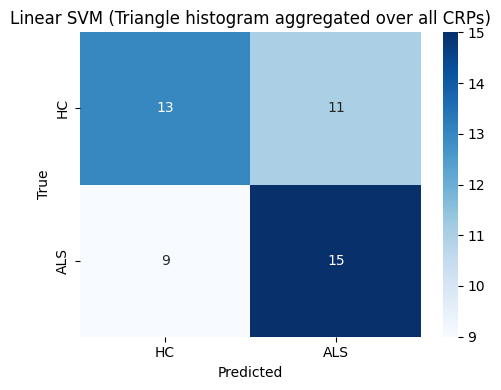

In [16]:

# ---- 特徴量作成 ----
# 注意:
# 156チャネルならペア数は 156*155/2 = 12090
# 157チャネルならペア数は 157*156/2 = 12246
# 計算がかなり重いので n_jobs を適宜調整してください

# Get the number of available CPU cores
num_cpus = os.cpu_count()
# Use a number close to the maximum, for example, all available cores
n_jobs_to_use = num_cpus if num_cpus is not None else 1

print(f"Using n_jobs = {n_jobs_to_use} (number of available CPU cores)")

X_feat = build_feature_matrix(
    X_subjects,
    L=4,
    percentage=0.1,
    normalize_each_pair=False,
    n_jobs=n_jobs_to_use
)

print("Feature matrix shape:", X_feat.shape)   # (n_subjects, 64)


# ---- 分類 ----
result = nested_cv_bayes_linear_svm(
    X_feat, y,
    n_splits_outer=5,
    n_splits_inner=3,
    n_iter=20,
    random_state=42
)

plot_confusion_matrix(result["confusion_sum"], class_names=("HC", "ALS"),
                      title="Linear SVM (Triangle histogram aggregated over all CRPs)")

In [18]:
# =========================================================
# 単一ペアCRP -> 再帰三角形特徴 -> SVM(C=100) で全ペア探索
# 自己ペア (i, i) も含む
# =========================================================

from itertools import combinations_with_replacement
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


# ---------------------------------------------------------
# 1患者・1ペア分の特徴量
# ---------------------------------------------------------
def subject_feature_from_single_pair(X_subject, ch_i, ch_j, L=4, percentage=0.1, normalize=True):
    """
    X_subject : np.ndarray, shape [T, C]
    ch_i, ch_j : 使用する2信号のインデックス
    L : 再帰三角形サイズ
    percentage : CRP の recurrence 閾値割合
    normalize : ヒストグラムを正規化するか

    Returns
    -------
    feat : np.ndarray, shape [2^(L*(L-1)/2)]
    """
    x = X_subject[:, ch_i]
    y = X_subject[:, ch_j]

    rp = cross_recurrence_plot_1d(x, y, percentage=percentage)
    feat = extract_triangle_histogram_from_rp(rp, L=L, normalize=normalize)
    return feat


# ---------------------------------------------------------
# 全患者について、指定1ペアの特徴行列を作る
# ---------------------------------------------------------
def build_feature_matrix_for_single_pair(X_subjects, ch_i, ch_j, L=4, percentage=0.1, normalize=True):
    feats = []
    for subj_idx, X_subject in enumerate(X_subjects):
        feat = subject_feature_from_single_pair(
            X_subject,
            ch_i=ch_i,
            ch_j=ch_j,
            L=L,
            percentage=percentage,
            normalize=normalize
        )
        feats.append(feat)
    return np.vstack(feats)


# ---------------------------------------------------------
# 単一ペア特徴に対する SVM(C=100) のCV評価
# ---------------------------------------------------------
def evaluate_single_pair_svm(
    X_pair, y,
    C=100.0,
    n_splits=5,
    random_state=42
):
    """
    X_pair : shape [n_subjects, n_features]
    y      : shape [n_subjects]
    """
    X_pair = np.asarray(X_pair, dtype=np.float64)
    y = np.asarray(y, dtype=np.int64)

    class_counts = np.bincount(y)
    min_class_count = class_counts.min()
    n_splits = min(n_splits, min_class_count)

    if n_splits < 2:
        raise ValueError(f"各クラスのサンプル数が少なすぎます: {class_counts}")

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    clf = SVC(kernel="linear", C=C, random_state=random_state)

    # OOF予測
    y_pred = cross_val_predict(clf, X_pair, y, cv=cv, n_jobs=None)

    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average="binary", zero_division=0)
    rec = recall_score(y, y_pred, average="binary", zero_division=0)
    f1 = f1_score(y, y_pred, average="binary", zero_division=0)
    cm = confusion_matrix(y, y_pred, labels=[0, 1])

    return {
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "confusion": cm,
        "y_pred": y_pred,
    }


# ---------------------------------------------------------
# 全ペア探索
# ---------------------------------------------------------
def search_best_single_pair_crp(
    fmri_data,
    n_signals=None,
    L=4,
    percentage=0.1,
    C=100.0,
    n_splits=5,
    random_state=42,
    sort_by="accuracy"
):
    """
    すべての信号ペア（自己ペア含む）について、
    CRP -> 再帰三角形特徴 -> SVM(C固定) で分類し、
    最良ペアを探す。

    Parameters
    ----------
    fmri_data : pd.DataFrame
    n_signals : int or None
        先頭n信号だけ使う。Noneなら全信号
    L : int
        再帰三角形サイズ
    percentage : float
        CRPの閾値割合
    C : float
        線形SVMのC
    n_splits : int
        StratifiedKFoldの分割数
    sort_by : str
        "accuracy" or "f1"

    Returns
    -------
    results_df : pd.DataFrame
    best_result : dict
    """
    subject_ids, X_subjects, y, signal_cols = build_subject_matrices(
        fmri_data,
        n_signals=n_signals
    )

    n_subjects = len(subject_ids)
    n_channels = len(signal_cols)

    print("======================================")
    print("Single-pair CRP search started")
    print(f"Number of subjects : {n_subjects}")
    print(f"Number of channels : {n_channels}")
    print(f"Class balance      : {np.bincount(y)}")
    print(f"L                  : {L}")
    print(f"percentage         : {percentage}")
    print(f"SVM C              : {C}")
    print("======================================")

    pair_list = list(combinations_with_replacement(range(n_channels), 2))
    total_pairs = len(pair_list)

    results = []

    for pair_idx, (i, j) in enumerate(pair_list, start=1):
        pair_name = f"({i},{j}) : {signal_cols[i]} vs {signal_cols[j]}"

        # 1ペア分の特徴行列
        X_pair = build_feature_matrix_for_single_pair(
            X_subjects,
            ch_i=i,
            ch_j=j,
            L=L,
            percentage=percentage,
            normalize=True
        )

        # 分類
        metrics = evaluate_single_pair_svm(
            X_pair,
            y,
            C=C,
            n_splits=n_splits,
            random_state=random_state
        )

        row = {
            "pair_index": pair_idx,
            "ch_i": i,
            "ch_j": j,
            "signal_i": signal_cols[i],
            "signal_j": signal_cols[j],
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "confusion": metrics["confusion"],
        }
        results.append(row)

        # 1ペア終わるごとにログ出力
        print(
            f"[{pair_idx}/{total_pairs}] {pair_name} | "
            f"Acc={metrics['accuracy']:.4f}, "
            f"Prec={metrics['precision']:.4f}, "
            f"Rec={metrics['recall']:.4f}, "
            f"F1={metrics['f1']:.4f}"
        )

    results_df = pd.DataFrame(results)

    if sort_by not in results_df.columns:
        sort_by = "accuracy"

    results_df = results_df.sort_values(
        by=[sort_by, "f1", "accuracy"],
        ascending=False
    ).reset_index(drop=True)

    best_row = results_df.iloc[0].to_dict()

    print("\n======================================")
    print("Best pair found")
    print(f"Rank-1 pair : ({best_row['ch_i']}, {best_row['ch_j']})")
    print(f"Signals     : {best_row['signal_i']} vs {best_row['signal_j']}")
    print(f"Accuracy    : {best_row['accuracy']:.4f}")
    print(f"Precision   : {best_row['precision']:.4f}")
    print(f"Recall      : {best_row['recall']:.4f}")
    print(f"F1          : {best_row['f1']:.4f}")
    print("Confusion:\n", best_row["confusion"])
    print("======================================")

    return results_df, best_row


# ---------------------------------------------------------
# 実行例
# ---------------------------------------------------------
# まずは軽量に試したいなら n_signals=10 など
# 本番で全信号を使うなら n_signals=None
results_df, best_result = search_best_single_pair_crp(
    fmri_data=fmri_data,
    n_signals=None,      # 例: まず軽く試すなら 10 や 20
    L=4,
    percentage=0.1,
    C=100.0,
    n_splits=5,
    random_state=42,
    sort_by="accuracy"
)


ストリーミング出力は最後の 5000 行に切り捨てられました。
[7262/12246] (56,121) : RH_Vis_7_Occipital_Mid_R vs RH-RN_RedNucleus | Acc=0.6667, Prec=0.7500, Rec=0.5000, F1=0.6000
[7263/12246] (56,122) : RH_Vis_7_Occipital_Mid_R vs RH-SNr_SubstantiaNigraReticulata | Acc=0.5833, Prec=0.6000, Rec=0.5000, F1=0.5455
[7264/12246] (56,123) : RH_Vis_7_Occipital_Mid_R vs RH-VeP_VentralPallidum | Acc=0.6458, Prec=0.7333, Rec=0.4583, F1=0.5641
[7265/12246] (56,124) : RH_Vis_7_Occipital_Mid_R vs RH-HN_HabenularNuclei | Acc=0.6458, Prec=0.6842, Rec=0.5417, F1=0.6047
[7266/12246] (56,125) : RH_Vis_7_Occipital_Mid_R vs RH-HTH_Hypothalamus | Acc=0.4792, Prec=0.4815, Rec=0.5417, F1=0.5098
[7267/12246] (56,126) : RH_Vis_7_Occipital_Mid_R vs RH-MN_MammillaryNucleus | Acc=0.6458, Prec=0.7059, Rec=0.5000, F1=0.5854
[7268/12246] (56,127) : RH_Vis_7_Occipital_Mid_R vs RH-STH_SubthalamicNucleus | Acc=0.6458, Prec=0.7333, Rec=0.4583, F1=0.5641
[7269/12246] (56,128) : RH_Vis_7_Occipital_Mid_R vs LH-Thal_Pulvinar | Acc=0.6042, Prec=0.5926, 

,pair_index,ch_i,ch_j,signal_i,signal_j,accuracy,precision,recall,f1,confusion
0,7236,56,95,RH_Vis_7_Occipital_Mid_R,RH_Default_PFCdPFCm_1_Frontal_Med_Orb_R,0.750000,0.687500,0.916667,0.785714,"[[14, 10], [2, 22]]"
1,7464,58,126,RH_SomMot_1_Temporal_Sup_R,RH-MN_MammillaryNucleus,0.750000,0.772727,0.708333,0.739130,"[[19, 5], [7, 17]]"
2,592,3,129,LH_Vis_4_Occipital_Mid_L,LH-Thal_Anterior,0.729167,0.657143,0.958333,0.779661,"[[12, 12], [1, 23]]"
3,1620,10,114,LH_SomMot_2_Rolandic_Oper_L,RH-Pu_Putamen,0.729167,0.666667,0.916667,0.771930,"[[13, 11], [2, 22]]"
4,599,3,136,LH_Vis_4_Occipital_Mid_L,RH-Thal_Anterior,0.729167,0.677419,0.875000,0.763636,"[[14, 10], [3, 21]]"
5,600,3,137,LH_Vis_4_Occipital_Mid_L,RH-Thal_MedialDorsal,0.729167,0.677419,0.875000,0.763636,"[[14, 10], [3, 21]]"
6,3237,22,57,LH_DorsAttn_FEF_1_Precentral_L,RH_Vis_8_Cuneus_R,0.729167,0.677419,0.875000,0.763636,"[[14, 10], [3, 21]]"
7,6258,47,53,LH_Default_PFC_7_Frontal_Mid_L,RH_Vis_4_Occipital_Inf_R,0.729167,0.677419,0.875000,0.763636,"[[14, 10], [3, 21]]"
8,6979,53,141,RH_Vis_4_Occipital_Inf_R,RH-Thal_VentralLateroVentral,0.729167,0.677419,0.875000,0.763636,"[[14, 10], [3, 21]]"
9,662,4,47,LH_Vis_5_Calcarine_L,LH_Default_PFC_7_Frontal_Mid_L,0.729167,0.689655,0.833333,0.754717,"[[15, 9], [4, 20]]"



=== Top 30 Self-Recurrence Signals ===


,channel_index,signal_name,accuracy,precision,recall,f1
0,57,RH_Vis_8_Cuneus_R,0.645833,0.612903,0.791667,0.690909
1,18,LH_DorsAttn_Post_4_Postcentral_L,0.645833,0.620690,0.750000,0.679245
2,67,RH_DorsAttn_Post_2_Postcentral_R,0.645833,0.620690,0.750000,0.679245
3,114,RH-Pu_Putamen,0.645833,0.684211,0.541667,0.604651
4,76,RH_SalVentAttn_Med_1_Cingulum_Mid_R,0.625000,0.588235,0.833333,0.689655
5,1,LH_Vis_2_Fusiform_L,0.625000,0.600000,0.750000,0.666667
6,92,RH_Default_Temp_3_Temporal_Mid_R,0.625000,0.607143,0.708333,0.653846
7,86,RH_Cont_Cing_1_Cingulum_Mid_R,0.625000,0.666667,0.500000,0.571429
8,64,RH_SomMot_7_Postcentral_R,0.604167,0.586207,0.708333,0.641509
9,69,RH_DorsAttn_Post_4_Parietal_Sup_R,0.604167,0.586207,0.708333,0.641509



=== Most Frequent Signals in Top 200 Pairs ===


,signal_name,count
0,LH_Vis_4_Occipital_Mid_L,45
1,RH_Vis_4_Occipital_Inf_R,29
2,RH_Vis_8_Cuneus_R,23
3,LH_Vis_5_Calcarine_L,20
4,RH_Default_PFCdPFCm_1_Frontal_Med_Orb_R,13
...,...,...
82,LH_SalVentAttn_FrOperIns_2_Insula_L,1
83,RH_Default_pCunPCC_2_Precuneus_R,1
84,RH_SalVentAttn_TempOccPar_1_Temporal_Sup_R,1
85,RH_Cont_PFCl_2_Frontal_Mid_R,1


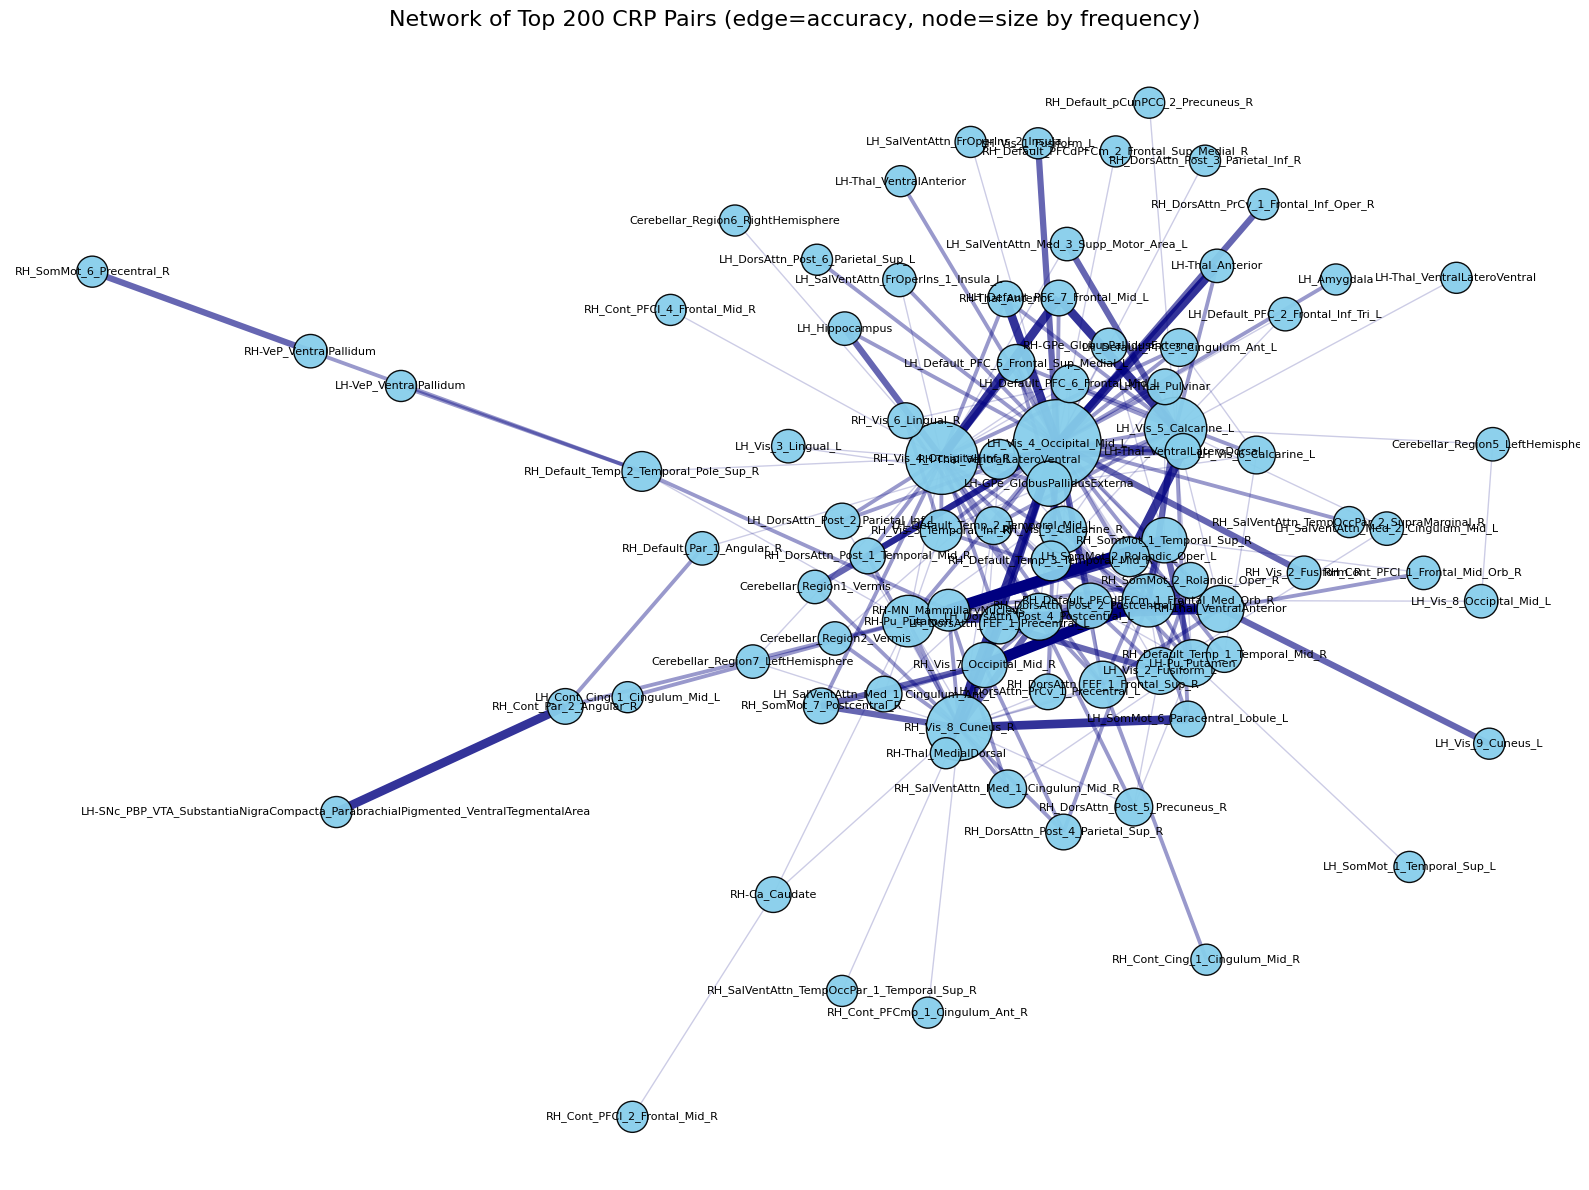

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter

# =========================================================
# 1) 自己再帰（i == j）の高精度信号を抽出
# =========================================================

def list_top_self_recurrence_signals(results_df, top_k=20, sort_by="accuracy"):
    """
    自己再帰ペア (ch_i == ch_j) のみを抽出し、
    高精度順に並べて返す
    """
    df_self = results_df[results_df["ch_i"] == results_df["ch_j"]].copy()

    if df_self.empty:
        print("自己再帰ペアが results_df に存在しません。")
        return df_self

    if sort_by not in df_self.columns:
        sort_by = "accuracy"

    df_self = df_self.sort_values(
        by=[sort_by, "f1", "precision", "recall"],
        ascending=False
    ).reset_index(drop=True)

    out = df_self[[
        "ch_i", "signal_i", "accuracy", "precision", "recall", "f1"
    ]].copy()
    out = out.rename(columns={
        "ch_i": "channel_index",
        "signal_i": "signal_name"
    })

    print(f"\n=== Top {min(top_k, len(out))} Self-Recurrence Signals ===")
    display(out.head(top_k))
    return out


# =========================================================
# 2) 上位200組の中で最多出現信号を集計
# =========================================================

def list_most_frequent_signals_in_top_pairs(results_df, top_k=200, sort_by="accuracy"):
    """
    上位top_kペアの中で、各信号が何回出たかを集計
    自己ペア(i,i)はその信号を1回として数える
    """
    if sort_by not in results_df.columns:
        sort_by = "accuracy"

    top_df = results_df.sort_values(
        by=[sort_by, "f1", "precision", "recall"],
        ascending=False
    ).head(top_k).copy()

    counter = Counter()

    for _, row in top_df.iterrows():
        sig_i = row["signal_i"]
        sig_j = row["signal_j"]

        if row["ch_i"] == row["ch_j"]:
            counter[sig_i] += 1
        else:
            counter[sig_i] += 1
            counter[sig_j] += 1

    freq_df = pd.DataFrame(
        [{"signal_name": k, "count": v} for k, v in counter.items()]
    ).sort_values("count", ascending=False).reset_index(drop=True)

    print(f"\n=== Most Frequent Signals in Top {min(top_k, len(top_df))} Pairs ===")
    display(freq_df)

    return top_df, freq_df


# =========================================================
# 3) 上位200組から networkx グラフを作成して可視化
#    - エッジ太さ/濃さ: 精度が高いほど大きく
#    - ノードサイズ: 出現頻度が高いほど大きく
# =========================================================

def plot_top_pairs_network(
    top_df,
    freq_df,
    weight_col="accuracy",
    title="Top Pair Network",
    figsize=(16, 12),
    layout_seed=42
):
    """
    top_df : 上位ペア dataframe
    freq_df: 信号出現頻度 dataframe
    weight_col: エッジ重みとして使う列（accuracy 推奨）
    """
    if weight_col not in top_df.columns:
        weight_col = "accuracy"

    G = nx.Graph()

    # ノード追加
    freq_map = dict(zip(freq_df["signal_name"], freq_df["count"]))

    for sig, cnt in freq_map.items():
        G.add_node(sig, count=cnt)

    # エッジ追加
    # 同じノード同士の自己ループは networkx 描画では見づらいので、
    # ここでは自己ループも保持するが、描画は別扱い
    self_loops = []

    for _, row in top_df.iterrows():
        sig_i = row["signal_i"]
        sig_j = row["signal_j"]
        w = float(row[weight_col])

        if sig_i == sig_j:
            self_loops.append((sig_i, w))
        else:
            if G.has_edge(sig_i, sig_j):
                # 既存エッジがある場合は、より高い精度を採用
                G[sig_i][sig_j]["weight"] = max(G[sig_i][sig_j]["weight"], w)
                G[sig_i][sig_j]["count"] += 1
            else:
                G.add_edge(sig_i, sig_j, weight=w, count=1)

    if len(G.nodes) == 0:
        print("描画対象のノードがありません。")
        return G

    # レイアウト
    pos = nx.spring_layout(G, seed=layout_seed, k=1.2 / np.sqrt(max(len(G.nodes), 1)))

    # ノードサイズ
    counts = np.array([G.nodes[n]["count"] for n in G.nodes()], dtype=float)
    if len(counts) > 0:
        cmin, cmax = counts.min(), counts.max()
        if cmax > cmin:
            node_sizes = 500 + 3500 * (counts - cmin) / (cmax - cmin)
        else:
            node_sizes = np.full_like(counts, 1500.0)
    else:
        node_sizes = []

    # エッジ太さ/濃さ
    edges = list(G.edges(data=True))
    weights = np.array([d["weight"] for _, _, d in edges], dtype=float) if edges else np.array([])

    if len(weights) > 0:
        wmin, wmax = weights.min(), weights.max()
        if wmax > wmin:
            edge_widths = 1.0 + 7.0 * (weights - wmin) / (wmax - wmin)
            edge_alphas = 0.2 + 0.8 * (weights - wmin) / (wmax - wmin)
        else:
            edge_widths = np.full_like(weights, 3.0)
            edge_alphas = np.full_like(weights, 0.8)
    else:
        edge_widths = np.array([])
        edge_alphas = np.array([])

    plt.figure(figsize=figsize)
    ax = plt.gca()
    ax.set_title(title, fontsize=16)

    # ノード
    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        node_color="skyblue",
        edgecolors="black",
        linewidths=1.0,
        alpha=0.95
    )

    # エッジ（濃さを個別に反映）
    for (u, v, d), width, alpha in zip(edges, edge_widths, edge_alphas):
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=[(u, v)],
            width=float(width),
            alpha=float(alpha),
            edge_color="navy"
        )

    # ラベル
    nx.draw_networkx_labels(
        G,
        pos,
        font_size=8
    )

    # 自己ループ情報をテキストで補足
    if len(self_loops) > 0:
        self_loop_df = pd.DataFrame(self_loops, columns=["signal_name", weight_col])
        self_loop_df = self_loop_df.sort_values(weight_col, ascending=False).reset_index(drop=True)

        txt = "Self-recurrence in top pairs:\n" + "\n".join(
            [f"{r.signal_name} ({weight_col}={r[weight_col]:.3f})"
             for _, r in self_loop_df.head(15).iterrows()]
        )
        plt.gcf().text(0.02, 0.02, txt, fontsize=8, va="bottom", ha="left",
                       bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray"))

    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return G


# =========================================================
# 4) 実行例
# =========================================================

# 4-1) 自己再帰で高精度な信号を一覧化
self_df = list_top_self_recurrence_signals(
    results_df,
    top_k=30,
    sort_by="accuracy"
)

# 4-2) 上位200組の出現頻度を集計
top200_df, freq_df = list_most_frequent_signals_in_top_pairs(
    results_df,
    top_k=200,
    sort_by="accuracy"
)

# 4-3) ネットワーク描画
G = plot_top_pairs_network(
    top200_df,
    freq_df,
    weight_col="accuracy",
    title="Network of Top 200 CRP Pairs (edge=accuracy, node=size by frequency)"
)

In [56]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# =========================================================
# 1) results_df の上位Kペアを取得
# =========================================================

def get_top_k_pairs(results_df, top_k=10, sort_by="accuracy"):
    if sort_by not in results_df.columns:
        sort_by = "accuracy"

    top_df = results_df.sort_values(
        by=[sort_by, "f1", "precision", "recall"],
        ascending=False
    ).head(top_k).reset_index(drop=True)

    pair_list = [(int(r["ch_i"]), int(r["ch_j"])) for _, r in top_df.iterrows()]

    print(f"=== Top {len(pair_list)} pairs ===")
    display(top_df[["ch_i", "ch_j", "signal_i", "signal_j", "accuracy", "precision", "recall", "f1"]])

    return top_df, pair_list


# =========================================================
# 2) 1患者について、複数ペアの特徴量を連結
#    ※ 同じパターン番号でもペアが違えば別特徴
# =========================================================

def subject_feature_from_selected_pairs(
    X_subject,
    pair_list,
    L=4,
    percentage=0.1,
    normalize_each_pair=True
):
    """
    X_subject : shape [T, C]
    pair_list : [(i,j), ...]
    Returns
    -------
    feat : shape [len(pair_list) * 2^(L*(L-1)/2)]
    """
    feats = []

    for ch_i, ch_j in pair_list:
        rp = cross_recurrence_plot_1d(
            X_subject[:, ch_i],
            X_subject[:, ch_j],
            percentage=percentage
        )
        hist = extract_triangle_histogram_from_rp(
            rp,
            L=L,
            normalize=normalize_each_pair
        )
        feats.append(hist)

    return np.concatenate(feats, axis=0)


# =========================================================
# 3) 全患者について特徴行列を作成
# =========================================================

def build_feature_matrix_for_selected_pairs(
    X_subjects,
    pair_list,
    L=4,
    percentage=0.1,
    normalize_each_pair=True,
    verbose=True
):
    X_feat = []

    n_subjects = len(X_subjects)
    for subj_idx, X_subject in enumerate(X_subjects, start=1):
        feat = subject_feature_from_selected_pairs(
            X_subject,
            pair_list=pair_list,
            L=L,
            percentage=percentage,
            normalize_each_pair=normalize_each_pair
        )
        X_feat.append(feat)

        if verbose:
            print(f"[Subject {subj_idx}/{n_subjects}] feature done -> shape {feat.shape}")

    return np.vstack(X_feat)


def evaluate_bayes_linear_svm(
    X, y,
    n_splits_outer=5,
    n_splits_inner=3,
    n_iter=20,
    random_state=42
):
    """
    BayesSearchCV により C と class_weight を探索する
    線形SVMのネスト交差検証評価
    """
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.int64)

    result = nested_cv_bayes_linear_svm(
        X, y,
        n_splits_outer=n_splits_outer,
        n_splits_inner=n_splits_inner,
        n_iter=n_iter,
        random_state=random_state
    )

    print("\n========== Final Summary ==========")
    print("Model     : Linear SVM + Bayes Optimization")
    print(f"Accuracy  : {result['accuracy_mean']:.4f} ± {result['accuracy_std']:.4f}")
    print(f"Precision : {result['precision_mean']:.4f}")
    print(f"Recall    : {result['recall_mean']:.4f}")
    print(f"F1        : {result['f1_mean']:.4f}")
    print("Confusion matrix:\n", result["confusion_sum"])
    print("\nBest params by fold:")
    for i, params in enumerate(result["best_params_each_fold"], start=1):
        print(f"  Fold {i}: {params}")

    return result

# =========================================================
# 4) 固定パラメータ SVM(C=100, linear) で分類
# =========================================================

def evaluate_fixed_linear_svm(
    X, y,
    C=100.0,
    n_splits=5,
    random_state=42
):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.int64)

    class_counts = np.bincount(y)
    min_class_count = class_counts.min()
    n_splits = min(n_splits, min_class_count)

    if n_splits < 2:
        raise ValueError(f"各クラスのサンプル数が少なすぎます: {class_counts}")

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    clf = SVC(kernel="linear", C=C, random_state=random_state)

    y_pred = cross_val_predict(clf, X, y, cv=cv)

    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average="binary", zero_division=0)
    rec = recall_score(y, y_pred, average="binary", zero_division=0)
    f1 = f1_score(y, y_pred, average="binary", zero_division=0)
    cm = confusion_matrix(y, y_pred, labels=[0, 1])

    print("\n========== Classification Result ==========")
    print(f"Model     : Linear SVM")
    print(f"C         : {C}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1        : {f1:.4f}")
    print("Confusion matrix:\n", cm)
    print("\nClassification report:")
    print(classification_report(y, y_pred, target_names=["HC", "ALS"], zero_division=0))

    return {
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "confusion": cm,
        "y_pred": y_pred,
    }


# =========================================================
# 5) 実行
# =========================================================

# 被験者ごとの時系列を作成
subject_ids, X_subjects, y, signal_cols = build_subject_matrices(
    fmri_data,
    n_signals=None
)

print("Number of subjects:", len(subject_ids))
print("Number of channels:", len(signal_cols))
print("Class balance:", np.bincount(y))

# 上位10ペアを取得
top10_df, top10_pairs = get_top_k_pairs(
    results_df,
    top_k=5,
    sort_by="accuracy"
)

print("\nSelected top-10 pairs:")
for rank, (i, j) in enumerate(top10_pairs, start=1):
    print(f"{rank:2d}. ({i}, {j}) : {signal_cols[i]} vs {signal_cols[j]}")

# 特徴量作成
# L=4 のとき 1ペア 64次元 → 10ペアで 640次元
X_feat_top10 = build_feature_matrix_for_selected_pairs(
    X_subjects,
    pair_list=top10_pairs,
    L=4,
    percentage=0.1,
    normalize_each_pair=True,   # 各ペアごとに頻度正規化
    verbose=True
)

print("\nFeature matrix shape:", X_feat_top10.shape)
print("Expected feature dim per subject:", len(top10_pairs) * (2 ** (4 * 3 // 2)))  # 10*64=640

# 分類
result_top10 = evaluate_bayes_linear_svm(
    X_feat_top10,
    y,
    n_splits_outer=5,
    n_splits_inner=3,
    n_iter=30,
    random_state=42
)

Number of subjects: 48
Number of channels: 156
Class balance: [24 24]
=== Top 5 pairs ===


,ch_i,ch_j,signal_i,signal_j,accuracy,precision,recall,f1
0,56,95,RH_Vis_7_Occipital_Mid_R,RH_Default_PFCdPFCm_1_Frontal_Med_Orb_R,0.750000,0.687500,0.916667,0.785714
1,58,126,RH_SomMot_1_Temporal_Sup_R,RH-MN_MammillaryNucleus,0.750000,0.772727,0.708333,0.739130
2,3,129,LH_Vis_4_Occipital_Mid_L,LH-Thal_Anterior,0.729167,0.657143,0.958333,0.779661
3,10,114,LH_SomMot_2_Rolandic_Oper_L,RH-Pu_Putamen,0.729167,0.666667,0.916667,0.771930
4,3,136,LH_Vis_4_Occipital_Mid_L,RH-Thal_Anterior,0.729167,0.677419,0.875000,0.763636



Selected top-10 pairs:
 1. (56, 95) : RH_Vis_7_Occipital_Mid_R vs RH_Default_PFCdPFCm_1_Frontal_Med_Orb_R
 2. (58, 126) : RH_SomMot_1_Temporal_Sup_R vs RH-MN_MammillaryNucleus
 3. (3, 129) : LH_Vis_4_Occipital_Mid_L vs LH-Thal_Anterior
 4. (10, 114) : LH_SomMot_2_Rolandic_Oper_L vs RH-Pu_Putamen
 5. (3, 136) : LH_Vis_4_Occipital_Mid_L vs RH-Thal_Anterior
[Subject 1/48] feature done -> shape (320,)
[Subject 2/48] feature done -> shape (320,)
[Subject 3/48] feature done -> shape (320,)
[Subject 4/48] feature done -> shape (320,)
[Subject 5/48] feature done -> shape (320,)
[Subject 6/48] feature done -> shape (320,)
[Subject 7/48] feature done -> shape (320,)
[Subject 8/48] feature done -> shape (320,)
[Subject 9/48] feature done -> shape (320,)
[Subject 10/48] feature done -> shape (320,)
[Subject 11/48] feature done -> shape (320,)
[Subject 12/48] feature done -> shape (320,)
[Subject 13/48] feature done -> shape (320,)
[Subject 14/48] feature done -> shape (320,)
[Subject 15/48] featu

In [42]:

# ---------------------------------------------------------
# 実行例
# ---------------------------------------------------------
# まずは軽量に試したいなら n_signals=10 など
# 本番で全信号を使うなら n_signals=None
results_df_5, best_result_5 = search_best_single_pair_crp(
    fmri_data=fmri_data,
    n_signals=None,      # 例: まず軽く試すなら 10 や 20
    L=5,
    percentage=0.1,
    C=100.0,
    n_splits=5,
    random_state=42,
    sort_by="accuracy"
)

ストリーミング出力は最後の 5000 行に切り捨てられました。
[7260/12246] (56,119) : RH_Vis_7_Occipital_Mid_R vs RH-GPi_GlobusPallidusInterna | Acc=0.4792, Prec=0.4783, Rec=0.4583, F1=0.4681
[7261/12246] (56,120) : RH_Vis_7_Occipital_Mid_R vs RH-SNc_PBP_VTA_SubstantiaNigraCompacta_ParabrachialPigmented_VentralTegmentalArea | Acc=0.6458, Prec=0.8182, Rec=0.3750, F1=0.5143
[7262/12246] (56,121) : RH_Vis_7_Occipital_Mid_R vs RH-RN_RedNucleus | Acc=0.6250, Prec=0.6875, Rec=0.4583, F1=0.5500
[7263/12246] (56,122) : RH_Vis_7_Occipital_Mid_R vs RH-SNr_SubstantiaNigraReticulata | Acc=0.5833, Prec=0.6000, Rec=0.5000, F1=0.5455
[7264/12246] (56,123) : RH_Vis_7_Occipital_Mid_R vs RH-VeP_VentralPallidum | Acc=0.6458, Prec=0.7333, Rec=0.4583, F1=0.5641
[7265/12246] (56,124) : RH_Vis_7_Occipital_Mid_R vs RH-HN_HabenularNuclei | Acc=0.6042, Prec=0.6190, Rec=0.5417, F1=0.5778
[7266/12246] (56,125) : RH_Vis_7_Occipital_Mid_R vs RH-HTH_Hypothalamus | Acc=0.4792, Prec=0.4828, Rec=0.5833, F1=0.5283
[7267/12246] (56,126) : RH_Vis_7_Oc


=== Top 30 Self-Recurrence Signals ===


,channel_index,signal_name,accuracy,precision,recall,f1
0,18,LH_DorsAttn_Post_4_Postcentral_L,0.687500,0.680000,0.708333,0.693878
1,106,LH-SNc_PBP_VTA_SubstantiaNigraCompacta_Parabra...,0.666667,0.722222,0.541667,0.619048
2,114,RH-Pu_Putamen,0.666667,0.750000,0.500000,0.600000
3,58,RH_SomMot_1_Temporal_Sup_R,0.645833,0.620690,0.750000,0.679245
4,64,RH_SomMot_7_Postcentral_R,0.645833,0.620690,0.750000,0.679245
5,133,LH-Thal_VentralAnterior,0.645833,0.620690,0.750000,0.679245
6,92,RH_Default_Temp_3_Temporal_Mid_R,0.645833,0.629630,0.708333,0.666667
7,56,RH_Vis_7_Occipital_Mid_R,0.645833,0.640000,0.666667,0.653061
8,55,RH_Vis_6_Lingual_R,0.645833,0.652174,0.625000,0.638298
9,65,RH_SomMot_8_Supp_Motor_Area_R,0.645833,0.666667,0.583333,0.622222



=== Most Frequent Signals in Top 200 Pairs ===


,signal_name,count
0,LH_Vis_4_Occipital_Mid_L,39
1,RH_Vis_4_Occipital_Inf_R,27
2,RH-Pu_Putamen,16
3,RH_SomMot_1_Temporal_Sup_R,15
4,RH_Vis_7_Occipital_Mid_R,15
...,...,...
84,RH_SomMot_2_Rolandic_Oper_R,1
85,RH_Vis_6_Lingual_R,1
86,RH_SomMot_5_Precentral_R,1
87,RH_DorsAttn_Post_1_Temporal_Mid_R,1


ValueError: 'alpha' must be between 0 and 1, inclusive

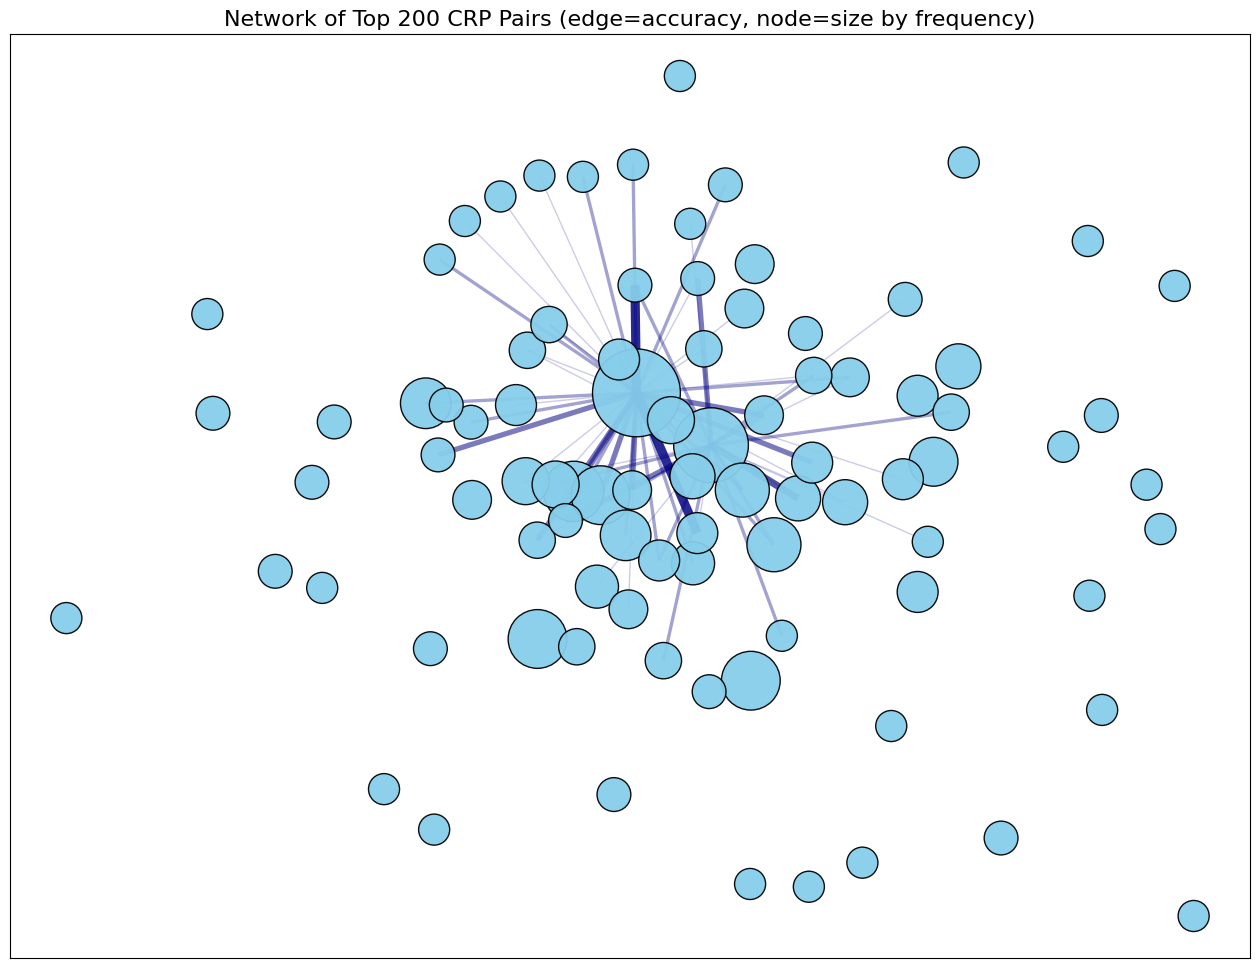

In [44]:

# =========================================================
# 4) 実行例
# =========================================================

# 4-1) 自己再帰で高精度な信号を一覧化
self_df = list_top_self_recurrence_signals(
    results_df_5,
    top_k=30,
    sort_by="accuracy"
)

# 4-2) 上位200組の出現頻度を集計
top200_df, freq_df = list_most_frequent_signals_in_top_pairs(
    results_df_5,
    top_k=200,
    sort_by="accuracy"
)

# 4-3) ネットワーク描画
G = plot_top_pairs_network(
    top200_df,
    freq_df,
    weight_col="accuracy",
    title="Network of Top 200 CRP Pairs (edge=accuracy, node=size by frequency)"
)

In [63]:

# 上位10ペアを取得
top10_df, top10_pairs = get_top_k_pairs(
    results_df_5,
    top_k=8,
    sort_by="accuracy"
)

print("\nSelected top-10 pairs:")
for rank, (i, j) in enumerate(top10_pairs, start=1):
    print(f"{rank:2d}. ({i}, {j}) : {signal_cols[i]} vs {signal_cols[j]}")

# 特徴量作成
# L=4 のとき 1ペア 64次元 → 10ペアで 640次元
X_feat_top10 = build_feature_matrix_for_selected_pairs(
    X_subjects,
    pair_list=top10_pairs,
    L=5,
    percentage=0.1,
    normalize_each_pair=True,   # 各ペアごとに頻度正規化
    verbose=True
)
# 上位10ペアを取得
top10_df, top10_pairs = get_top_k_pairs(
    results_df,
    top_k=5,
    sort_by="accuracy"
)

print("\nSelected top-10 pairs:")
for rank, (i, j) in enumerate(top10_pairs, start=1):
    print(f"{rank:2d}. ({i}, {j}) : {signal_cols[i]} vs {signal_cols[j]}")

# 特徴量作成
# L=4 のとき 1ペア 64次元 → 10ペアで 640次元
X_feat_top10 = build_feature_matrix_for_selected_pairs(
    X_subjects,
    pair_list=top10_pairs,
    L=4,
    percentage=0.1,
    normalize_each_pair=True,   # 各ペアごとに頻度正規化
    verbose=True
)

print("\nFeature matrix shape:", X_feat_top10.shape)
print("Expected feature dim per subject:", len(top10_pairs) * (2 ** (4 * 3 // 2)))  # 10*64=640

# 分類
result_top10 = evaluate_fixed_linear_svm(
    X_feat_top10,
    y,
    C=100.0,
    n_splits=5,
    random_state=42
)

print("\nFeature matrix shape:", X_feat_top10.shape)
print("Expected feature dim per subject:", len(top10_pairs) * (2 ** (4 * 3 // 2)))  # 10*64=640

# 分類
result_top10 = evaluate_bayes_linear_svm(
    X_feat_top10,
    y,
    n_splits_outer=5,
    n_splits_inner=3,
    n_iter=20,
    random_state=42
)

=== Top 8 pairs ===


,ch_i,ch_j,signal_i,signal_j,accuracy,precision,recall,f1
0,10,114,LH_SomMot_2_Rolandic_Oper_L,RH-Pu_Putamen,0.791667,0.791667,0.791667,0.791667
1,24,114,LH_SalVentAttn_FrOperIns_1_Insula_L,RH-Pu_Putamen,0.791667,0.791667,0.791667,0.791667
2,3,92,LH_Vis_4_Occipital_Mid_L,RH_Default_Temp_3_Temporal_Mid_R,0.770833,0.724138,0.875000,0.792453
3,52,95,RH_Vis_3_Temporal_Inf_R,RH_Default_PFCdPFCm_1_Frontal_Med_Orb_R,0.770833,0.724138,0.875000,0.792453
4,3,67,LH_Vis_4_Occipital_Mid_L,RH_DorsAttn_Post_2_Postcentral_R,0.770833,0.740741,0.833333,0.784314
5,114,133,RH-Pu_Putamen,LH-Thal_VentralAnterior,0.770833,0.740741,0.833333,0.784314
6,36,114,LH_Cont_Cing_1_Cingulum_Mid_L,RH-Pu_Putamen,0.770833,0.760000,0.791667,0.775510
7,24,58,LH_SalVentAttn_FrOperIns_1_Insula_L,RH_SomMot_1_Temporal_Sup_R,0.750000,0.687500,0.916667,0.785714



Selected top-10 pairs:
 1. (10, 114) : LH_SomMot_2_Rolandic_Oper_L vs RH-Pu_Putamen
 2. (24, 114) : LH_SalVentAttn_FrOperIns_1_Insula_L vs RH-Pu_Putamen
 3. (3, 92) : LH_Vis_4_Occipital_Mid_L vs RH_Default_Temp_3_Temporal_Mid_R
 4. (52, 95) : RH_Vis_3_Temporal_Inf_R vs RH_Default_PFCdPFCm_1_Frontal_Med_Orb_R
 5. (3, 67) : LH_Vis_4_Occipital_Mid_L vs RH_DorsAttn_Post_2_Postcentral_R
 6. (114, 133) : RH-Pu_Putamen vs LH-Thal_VentralAnterior
 7. (36, 114) : LH_Cont_Cing_1_Cingulum_Mid_L vs RH-Pu_Putamen
 8. (24, 58) : LH_SalVentAttn_FrOperIns_1_Insula_L vs RH_SomMot_1_Temporal_Sup_R
[Subject 1/48] feature done -> shape (8192,)
[Subject 2/48] feature done -> shape (8192,)
[Subject 3/48] feature done -> shape (8192,)
[Subject 4/48] feature done -> shape (8192,)
[Subject 5/48] feature done -> shape (8192,)
[Subject 6/48] feature done -> shape (8192,)
[Subject 7/48] feature done -> shape (8192,)
[Subject 8/48] feature done -> shape (8192,)
[Subject 9/48] feature done -> shape (8192,)
[Subjec

,ch_i,ch_j,signal_i,signal_j,accuracy,precision,recall,f1
0,56,95,RH_Vis_7_Occipital_Mid_R,RH_Default_PFCdPFCm_1_Frontal_Med_Orb_R,0.750000,0.687500,0.916667,0.785714
1,58,126,RH_SomMot_1_Temporal_Sup_R,RH-MN_MammillaryNucleus,0.750000,0.772727,0.708333,0.739130
2,3,129,LH_Vis_4_Occipital_Mid_L,LH-Thal_Anterior,0.729167,0.657143,0.958333,0.779661
3,10,114,LH_SomMot_2_Rolandic_Oper_L,RH-Pu_Putamen,0.729167,0.666667,0.916667,0.771930
4,3,136,LH_Vis_4_Occipital_Mid_L,RH-Thal_Anterior,0.729167,0.677419,0.875000,0.763636



Selected top-10 pairs:
 1. (56, 95) : RH_Vis_7_Occipital_Mid_R vs RH_Default_PFCdPFCm_1_Frontal_Med_Orb_R
 2. (58, 126) : RH_SomMot_1_Temporal_Sup_R vs RH-MN_MammillaryNucleus
 3. (3, 129) : LH_Vis_4_Occipital_Mid_L vs LH-Thal_Anterior
 4. (10, 114) : LH_SomMot_2_Rolandic_Oper_L vs RH-Pu_Putamen
 5. (3, 136) : LH_Vis_4_Occipital_Mid_L vs RH-Thal_Anterior
[Subject 1/48] feature done -> shape (320,)
[Subject 2/48] feature done -> shape (320,)
[Subject 3/48] feature done -> shape (320,)
[Subject 4/48] feature done -> shape (320,)
[Subject 5/48] feature done -> shape (320,)
[Subject 6/48] feature done -> shape (320,)
[Subject 7/48] feature done -> shape (320,)
[Subject 8/48] feature done -> shape (320,)
[Subject 9/48] feature done -> shape (320,)
[Subject 10/48] feature done -> shape (320,)
[Subject 11/48] feature done -> shape (320,)
[Subject 12/48] feature done -> shape (320,)
[Subject 13/48] feature done -> shape (320,)
[Subject 14/48] feature done -> shape (320,)
[Subject 15/48] featu